In [ ]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import statsmodels.formula.api as smf

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, make_scorer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, StratifiedKFold, KFold
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.pipeline import Pipeline

import shap

import scipy.stats as stats
import time
import warnings
warnings.filterwarnings('ignore')

C:\Users\SIERRAR2115\MUBA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# CONFIGURACION

In [ ]:
SECTOR = '90'
# '45'

# 1 Carga de datos

Cargamos los distintos archivos (1 para cada año)

In [ ]:
df21 = pd.read_excel(r'C:\Users\SIERRAR2115\MUBA\TFM\2021.xlsx')
df21.head()

,Identificador,Link licitación,Fecha actualización,Vigente/Anulada/Archivada,Primera publicación,Estado,Número de expediente,Objeto del Contrato,Identificador único TED,Valor estimado del contrato,...,Se han excluído ofertas por ser anormalmente bajas por licitación/lote,Número del contrato licitación/lote,Fecha formalización del contrato licitación/lote,Fecha entrada en vigor del contrato de licitación/lote,Adjudicatario licitación/lote,Tipo de identificador de adjudicatario por licitación/lote,Identificador Adjudicatario de la licitación/lote,El adjudicatario es o no PYME de la licitación/lote,Importe adjudicación sin impuestos licitación/lote,Importe adjudicación con impuestos licitación/lote
0,8994792,https://contrataciondelestado.es/wps/poc?uri=d...,2021-12-30 21:55:04.097,VIGENTE,2021-12-30,En plazo,68-007904-A0,Redacción de proyecto básico y de ejecución de...,NaN,110160.00,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1,8689190,https://contrataciondelestado.es/wps/poc?uri=d...,2021-12-30 21:54:41.986,VIGENTE,2021-11-15,Resuelta,300/2021/00220,"Escuela de deportes alternativos, para el fome...",NaN,40033.24,...,NaN,42/2021,2021-12-30,2022-01-01,Asociación MASI (Monitores de Apoyo Social a l...,NIF,G82270489,NaN,20000.00,24200.00
2,8994793,https://contrataciondelestado.es/wps/poc?uri=d...,2021-12-30 21:39:55.162,VIGENTE,2021-12-30,En plazo,COPAS09/2021,Aglomerado de vial del lugar de Rilo al lugar ...,NaN,111779.93,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
3,8723412,https://contrataciondelestado.es/wps/poc?uri=d...,2021-12-30 21:38:52.376,VIGENTE,2021-11-18,Adjudicada,2021/066 PASS,Suministro (Suscripción) de licencias de softw...,NaN,26582.40,...,NaN,NaN,NaT,NaT,"MAKESOFT TECHNOLOGIES, SL",NIF,B84852391,NaN,17656.32,21364.15
4,8994794,https://contrataciondelestado.es/wps/poc?uri=d...,2021-12-30 21:34:30.936,VIGENTE,2021-12-30,En plazo,57/2021,Arrendamiento inmueble destinado a BAR del Hog...,NaN,1800.00,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df22 = pd.read_excel(r'C:\Users\SIERRAR2115\MUBA\TFM\2022.xlsx')
df22.head()

,Identificador,Link licitación,Fecha actualización,Vigente/Anulada/Archivada,Primera publicación,Estado,Número de expediente,Objeto del Contrato,Identificador único TED,Valor estimado del contrato,...,Se han excluído ofertas por ser anormalmente bajas por licitación/lote,Número del contrato licitación/lote,Fecha formalización del contrato licitación/lote,Fecha entrada en vigor del contrato de licitación/lote,Adjudicatario licitación/lote,Tipo de identificador de adjudicatario por licitación/lote,Identificador Adjudicatario de la licitación/lote,El adjudicatario es o no PYME de la licitación/lote,Importe adjudicación sin impuestos licitación/lote,Importe adjudicación con impuestos licitación/lote
0,11864551,https://contrataciondelestado.es/wps/poc?uri=d...,2022-12-31 16:49:31.913,VIGENTE,2022-12-31,Adjudicada,20056/2022,Contrato basado de audiovisuales necesarios pa...,NaN,965.00,...,NaN,20056/2022,2022-11-28,NaT,Hi Vision Producciones S.L,NIF,B35366806,1.0,965.0,1032.55
1,11864552,https://contrataciondelestado.es/wps/poc?uri=d...,2022-12-31 16:45:07.368,VIGENTE,2022-12-31,En plazo,288/2022,projecte d'extensio de xarxa d'aigues residual...,NaN,86943.91,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
2,11864553,https://contrataciondelestado.es/wps/poc?uri=d...,2022-12-31 16:42:36.349,VIGENTE,2022-12-31,Resuelta,19771/2022,Contrato basado de servicios necesarios para l...,NaN,4782.00,...,NaN,19771/2022,2022-11-28,NaT,PREVENTOS MEDIA SL,NIF,B76019348,1.0,4782.0,5117.60
3,10186559,https://contrataciondelestado.es/wps/poc?uri=d...,2022-12-31 16:23:45.592,VIGENTE,2022-05-26,Resuelta,19/2022,Contrato de servicios de gestión y asistencia ...,NaN,14700000.00,...,NaN,19/2022,2022-12-29,2023-01-01,VIAJES EL CORTE INGLÉS S.A.,NIF,A28229813,0.0,4900000.0,5390000.00
4,11864554,https://contrataciondelestado.es/wps/poc?uri=d...,2022-12-31 15:53:28.165,VIGENTE,2022-12-31,En plazo,474/2022,El objeto del presente Pliego es la contrataci...,NaN,238200.00,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df23 = pd.read_excel(r'C:\Users\SIERRAR2115\MUBA\TFM\2023.xlsx')
df23.head()

,Identificador,Link licitación,Fecha actualización,Vigente/Anulada/Archivada,Primera publicación,Estado,Número de expediente,Objeto del Contrato,Identificador único TED,Valor estimado del contrato,...,Se han excluído ofertas por ser anormalmente bajas por licitación/lote,Número del contrato licitación/lote,Fecha formalización del contrato licitación/lote,Fecha entrada en vigor del contrato de licitación/lote,Adjudicatario licitación/lote,Tipo de identificador de adjudicatario por licitación/lote,Identificador Adjudicatario de la licitación/lote,El adjudicatario es o no PYME de la licitación/lote,Importe adjudicación sin impuestos licitación/lote,Importe adjudicación con impuestos licitación/lote
0,13490545,https://contrataciondelestado.es/wps/poc?uri=d...,2023-12-31 16:49:06.721,VIGENTE,2023-10-09,Resuelta,2023/ETHC00006/00000189E,ASA Suministro de productos alimenticios para ...,NaN,57956.34,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1,13490545,https://contrataciondelestado.es/wps/poc?uri=d...,2023-12-31 16:49:06.721,VIGENTE,2023-10-09,Resuelta,2023/ETHC00006/00000189E,ASA Suministro de productos alimenticios para ...,NaN,57956.34,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
2,13490545,https://contrataciondelestado.es/wps/poc?uri=d...,2023-12-31 16:49:06.721,VIGENTE,2023-10-09,Resuelta,2023/ETHC00006/00000189E,ASA Suministro de productos alimenticios para ...,NaN,57956.34,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
3,13490545,https://contrataciondelestado.es/wps/poc?uri=d...,2023-12-31 16:49:06.721,VIGENTE,2023-10-09,Resuelta,2023/ETHC00006/00000189E,ASA Suministro de productos alimenticios para ...,NaN,57956.34,...,NaN,2023/ETHC00006/00000189E LOTE 4,2023-12-19,NaT,"FRUTAS MACIAS VERA, S.L.",NIF,B18711242,1.0,3295.45,3427.27
4,13490545,https://contrataciondelestado.es/wps/poc?uri=d...,2023-12-31 16:49:06.721,VIGENTE,2023-10-09,Resuelta,2023/ETHC00006/00000189E,ASA Suministro de productos alimenticios para ...,NaN,57956.34,...,NaN,2023/ETHC00006/00000189E LOTE 5,2023-12-19,NaT,"TU SUPER PURCHASE, S.L.",OTROS,B18762252,1.0,7488.90,8237.79


In [ ]:
df24 = pd.read_excel(r'C:\Users\SIERRAR2115\MUBA\TFM\2024.xlsx')
df24.head()

,Identificador,Link licitación,Fecha actualización,Vigente/Anulada/Archivada,Primera publicación,Estado,Número de expediente,Objeto del Contrato,Identificador único TED,Valor estimado del contrato,...,Se han excluído ofertas por ser anormalmente bajas por licitación/lote,Número del contrato licitación/lote,Fecha formalización del contrato licitación/lote,Fecha entrada en vigor del contrato de licitación/lote,Adjudicatario licitación/lote,Tipo de identificador de adjudicatario por licitación/lote,Identificador Adjudicatario de la licitación/lote,El adjudicatario es o no PYME de la licitación/lote,Importe adjudicación sin impuestos licitación/lote,Importe adjudicación con impuestos licitación/lote
0,15838726,https://contrataciondelestado.es/wps/poc?uri=d...,2024-12-30 16:58:10.804,VIGENTE,2024-10-10,Pendiente de adjudicación,24/07080,Contratación las obras de reforma de sala de m...,NaN,180000.00,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1,15606195,https://contrataciondelestado.es/wps/poc?uri=d...,2024-12-30 16:57:29.873,VIGENTE,2024-09-04,Pendiente de adjudicación,58/S/24/SS/CO/A/0001,Servicio de limpieza y otros servicios auxilia...,5cda3be0-be5a-4b9c-a4ad-2bccc19c4dc1,3870682.64,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
2,16240015,https://contrataciondelestado.es/wps/poc?uri=d...,2024-12-30 16:56:44.952,VIGENTE,2024-12-09,Resuelta,42/2024,Seguro de Ciberseguridad para Enwesa Operacion...,NaN,19500.00,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
3,16026766,https://contrataciondelestado.es/wps/poc?uri=d...,2024-12-30 16:56:34.569,VIGENTE,2024-11-08,Resuelta,PRC/2024/0000118579,Obras de Restauración de la Ermita de San Jorg...,NaN,318028.16,...,NaN,NaN,2024-12-29 00:00:00,NaT,CONSTRUCCIONES ABREU S.A.,NIF,A10007516,1.0,311190.55,376540.57
4,16391044,https://contrataciondelestado.es/wps/poc?uri=d...,2024-12-30 16:56:00.328,VIGENTE,2024-12-30,En plazo,010/2024,Actualización del Proyecto de Urbanización Hoy...,NaN,53476.03,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df25 = pd.read_excel(r'C:\Users\SIERRAR2115\MUBA\TFM\2025.xlsx')
df25.head()

,Identificador,Link licitación,Fecha actualización,Vigente/Anulada/Archivada,Primera publicación,Estado,Número de expediente,Objeto del Contrato,Identificador único TED,Valor estimado del contrato,...,Se han excluído ofertas por ser anormalmente bajas por licitación/lote,Número del contrato licitación/lote,Fecha formalización del contrato licitación/lote,Fecha entrada en vigor del contrato de licitación/lote,Adjudicatario licitación/lote,Tipo de identificador de adjudicatario por licitación/lote,Identificador Adjudicatario de la licitación/lote,El adjudicatario es o no PYME de la licitación/lote,Importe adjudicación sin impuestos licitación/lote,Importe adjudicación con impuestos licitación/lote
0,18526649,https://contrataciondelestado.es/wps/poc?uri=d...,2025-12-29 18:57:52.718,VIGENTE,2025-12-04,Adjudicada,S-05669-2025,Alquiler equipos filmación- Benidorm Fest 2026,NaN,195000.00,...,NaN,NaN,NaN,NaT,"SERVEIS DE PRODUCCIÓ MUXART, S.L.",NIF,B60707239,1.0,42500.00,51425.00
1,18526649,https://contrataciondelestado.es/wps/poc?uri=d...,2025-12-29 18:57:52.718,VIGENTE,2025-12-04,Adjudicada,S-05669-2025,Alquiler equipos filmación- Benidorm Fest 2026,NaN,195000.00,...,NaN,NaN,NaN,NaT,"SERVEIS DE PRODUCCIÓ MUXART, S.L.",NIF,B60707239,1.0,47350.00,57293.50
2,18526649,https://contrataciondelestado.es/wps/poc?uri=d...,2025-12-29 18:57:52.718,VIGENTE,2025-12-04,Adjudicada,S-05669-2025,Alquiler equipos filmación- Benidorm Fest 2026,NaN,195000.00,...,NaN,NaN,NaN,NaT,"SERVEIS DE PRODUCCIÓ MUXART, S.L.",NIF,B60707239,1.0,88000.00,106480.00
3,18735461,https://contrataciondelestado.es/wps/poc?uri=d...,2025-12-29 18:57:41.525,VIGENTE,2025-12-29,Adjudicada,2025/0277E,Estudio de Definición de la Plataforma Aérea T...,NaN,16000000.00,...,NaN,NaN,NaN,NaT,UTE PEM SCAPA,NIF,U24891541,0.0,16000000.00,16000000.00
4,17724367,https://contrataciondelestado.es/wps/poc?uri=d...,2025-12-29 18:50:21.035,VIGENTE,2025-07-23,Resuelta,30.2025,El objeto del contrato será el servicio consis...,6a50d70c-3602-483a-bc9f-5b44b9d472d7,645025.68,...,0.0,11,2025-11-14 00:00:00,2025-12-01,ASOCIACION CANARIA PARA LA POTENCIACION DEL DE...,NIF,G76621036,1.0,143096.59,153113.35


In [ ]:
df26 = pd.read_excel(r'C:\Users\SIERRAR2115\MUBA\TFM\2026.xlsx')
df26.head()

,Identificador,Link licitación,Fecha actualización,Vigente/Anulada/Archivada,Primera publicación,Estado,Número de expediente,Objeto del Contrato,Identificador único TED,Valor estimado del contrato,...,Se han excluído ofertas por ser anormalmente bajas por licitación/lote,Número del contrato licitación/lote,Fecha formalización del contrato licitación/lote,Fecha entrada en vigor del contrato de licitación/lote,Adjudicatario licitación/lote,Tipo de identificador de adjudicatario por licitación/lote,Identificador Adjudicatario de la licitación/lote,El adjudicatario es o no PYME de la licitación/lote,Importe adjudicación sin impuestos licitación/lote,Importe adjudicación con impuestos licitación/lote
0,18320267,https://contrataciondelestado.es/wps/poc?uri=d...,2026-02-12 18:56:34.242,VIGENTE,2025-11-05,Adjudicada,150/2025-1,Servicio de Asistencia Jurídica y de Represent...,NaN,300000.00,...,0.0,NaN,NaT,NaT,CREMADES & CALVO-SOTELO ABOGADOS SEVILLA SLP,NIF,B91595959,1.0,49400.00,59774.00
1,18956015,https://contrataciondelestado.es/wps/poc?uri=d...,2026-02-12 18:55:43.975,VIGENTE,2026-02-02,En plazo,MNTB26-021,Contratación del servicio de transporte especi...,NaN,152400.00,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
2,19025939,https://contrataciondelestado.es/wps/poc?uri=d...,2026-02-12 18:54:56.387,VIGENTE,NaT,Anuncio Previo,2026 GEN PID 04 EXPERIENCIA INMERSIVA,Servicios necesarios para el desarrollo del mó...,8c0640b8-b169-4a6f-89fb-037033eecb5f,452892.58,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
3,19025940,https://contrataciondelestado.es/wps/poc?uri=d...,2026-02-12 18:45:00.543,VIGENTE,2026-02-12,Resuelta,2688/2025,Plataforma tecnológica de Administración elect...,NaN,97771.62,...,NaN,2688/2025,2025-07-30,2025-07-30,ESPUBLICO SERVICIOS PARA LA ADMINISTRACIÓN SA,OTROS,A50878842,1.0,97771.62,118303.66
4,19025941,https://contrataciondelestado.es/wps/poc?uri=d...,2026-02-12 18:43:02.286,VIGENTE,2026-02-12,En plazo,EXP 122/25,"Contrato de obra de reforma Plaza de Toros, ""E...",NaN,182191.99,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN


Unificamos los archivos en un único dataset

In [ ]:
# Añadir columna de año a cada df
df21['Año'] = 2021
df22['Año'] = 2022
df23['Año'] = 2023
df24['Año'] = 2024
df25['Año'] = 2025
df26['Año'] = 2026

# Crear una lista con todos ellos
lista_dfs = [df21, df22, df23, df24, df25, df26]

# Conectar todos en uno solo (df conjunto)
# ignore_index=True para que el índice sea continuo
df = pd.concat(lista_dfs, ignore_index=True)

# Verificar que esté bien
print(f"Filas totales: {len(df)}")
print(df['Año'].value_counts()) # filas por año

Filas totales: 1365518
Año
2025    305946
2024    281873
2023    269337
2022    243936
2021    206397
2026     58029
Name: count, dtype: int64


# 2 Limpieza

Nos quedamos únicamente con licitaciones adjudicadas o resueltas, no queremos las que todavía se están licitando.

Queremos solamente los sectores de interés para nuestra empresa: Construcción (45) y Medio Ambiente (90)

In [ ]:
# Filtrar estados válidos (Adjudicada o Resuelta)
df = df[df['Estado'].isin(['Adjudicada', 'Resuelta'])]

# Filtrar sectores de interés por CPV - 45 = Construcción, 90 = Medio Ambiente
df = df[df['CPV licitación/lote'].astype(str).str.startswith(('45', '90'))]

# Eliminar nulos críticos
df = df.dropna(subset=[
    'Presupuesto base sin impuestos',
    'Importe adjudicación sin impuestos licitación/lote',
    'Fecha de presentación de ofertas',
    'CPV'
])

Eliminamos columnas que provoquen data lekeage

In [ ]:
# Eliminar columnas con data leakage
cols_leakage = [
    'Resultado licitación/lote', 'Fecha del acuerdo licitación/lote',
    'Precio de la oferta más baja por licitación/lote',
    'Precio de la oferta más alta por licitación/lote',
    'Se han excluído ofertas por ser anormalmente bajas',
    'Fecha formalización del contrato licitación/lote',
    'Fecha entrada en vigor del contrato de licitación/lote',
    'Adjudicatario licitación/lote',
    'Tipo de identificador de adjudicatario por licitación/lote',
    'Identificador Adjudicatario',
    'El adjudicatario es o no PYME',
    'Se han excluído ofertas por ser anormalmente bajas por licitación/lote',
    'Identificador Adjudicatario de la licitación/lote',
    'El adjudicatario es o no PYME de la licitación/lote',
    'Vigente/Anulada/Archivada', 'Estado'
]
df = df.drop(columns=cols_leakage, errors='ignore')

In [ ]:
df.isnull().sum()

Identificador                                                 0
Link licitación                                               0
Fecha actualización                                           0
Primera publicación                                           0
Número de expediente                                          0
Objeto del Contrato                                           0
Identificador único TED                                  164950
Valor estimado del contrato                                 378
Presupuesto base sin impuestos                                0
Presupuesto base con impuestos                                0
CPV                                                           0
Tipo de contrato                                              0
Contrato mixto                                           100301
Lugar de ejecución                                            0
Órgano de Contratación                                        0
ID OC en PLACSP                         

In [ ]:
# Eliminar columnas redundantes o con >50% nulos
cols_drop = [
    'Valor estimado del contrato',
    'Presupuesto base con impuestos', 'Presupuesto base con impuestos licitación/lote',
    'Fecha de presentación de solicitudes de participacion',
    'Subcontratación permitida porcentaje', 'Contrato mixto', 'Subcontratación permitida',
    'Identificador', 'Número de expediente', 'Identificador único TED',
    'ID OC en PLACSP', 'NIF OC', 'DIR3', 'Número de expediente.1',
    'Número del contrato licitación/lote', 'Link licitación',
    'Enlace al Perfil de Contratante del OC',
    'Descripción de la financiación europea', 'Fecha actualización', 'Primera publicación', 'Valor estimado licitación/lote'
]
df = df.drop(columns=cols_drop, errors='ignore')

Imputamos nulos de forma conservadora. Si está vacío lo más normal es que sea 'NO'.

In [ ]:
# Imputar nulos de columnas regulatorias
# Si está vacío, la interpretación correcta es 'No'
df['Financiación Europea y fuente'] = np.where(
    df['Financiación Europea y fuente'].str.startswith('Sí', na=False), 'Si', 'No'
)
for col in ['Contrato SARA/Umbral', 'Subasta electrónica']:
    df[col] = df[col].fillna('No')
df['Directiva de aplicación'] = df['Directiva de aplicación'].fillna('No aplica')

# Sistema de contratación: imputar con la moda
df['Sistema de contratación'] = df['Sistema de contratación'].fillna(
    df['Sistema de contratación'].mode()[0]
)

print(f"Shape tras limpieza: {df.shape}")

Shape tras limpieza: (175967, 26)


In [ ]:
df.isnull().sum()

Objeto del Contrato                                   0
Presupuesto base sin impuestos                        0
CPV                                                   0
Tipo de contrato                                      0
Lugar de ejecución                                    0
Órgano de Contratación                                0
Tipo de Administración                                0
Código Postal                                         0
Tipo de procedimiento                                 0
Sistema de contratación                               0
Tramitación                                           0
Forma de presentación de la oferta                    0
Fecha de presentación de ofertas                      0
Directiva de aplicación                               0
Contrato SARA/Umbral                                  0
Financiación Europea y fuente                         0
Subasta electrónica                                   0
Lote                                            

# 3 Feature Engineering

Un primer gráfico para ver los descuentos existentes

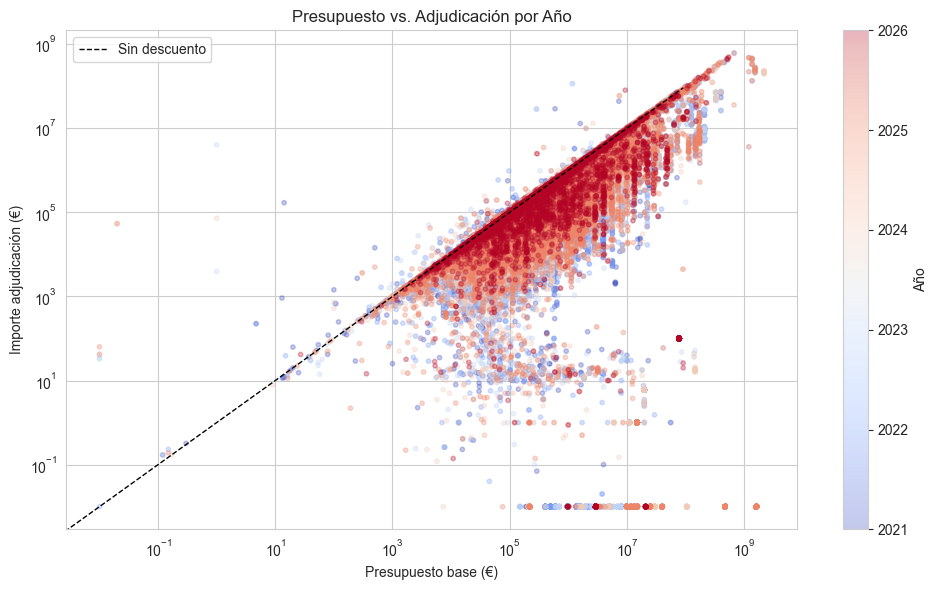

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df['Presupuesto base sin impuestos'],
    df['Importe adjudicación sin impuestos licitación/lote'],
     c=df['Año'],
    cmap='coolwarm',
    alpha=0.3,
    s=10
)

# Línea de referencia: adjudicación = presupuesto (descuento = 0)
max_val = df['Presupuesto base sin impuestos'].quantile(0.99)
ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1, label='Sin descuento')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Presupuesto base (€)')
ax.set_ylabel('Importe adjudicación (€)')
ax.set_title('Presupuesto vs. Adjudicación por Año')
plt.colorbar(scatter, ax=ax, label='Año')
ax.legend()
plt.tight_layout()
plt.show()

Creamos la variable objetivo 'Target_Descuento' y eliminamos columnas de importes para evitar data leakage

In [ ]:
# Variable objetivo: Descuento (%)
df['Target_Descuento'] = (
    (df['Presupuesto base sin impuestos'] - df['Importe adjudicación sin impuestos licitación/lote'])
    / df['Presupuesto base sin impuestos'] * 100
).round(2)

# Eliminar el importe de adjudicación (data leakage)
df = df.drop(columns=['Importe adjudicación sin impuestos licitación/lote',
                       'Importe adjudicación con impuestos licitación/lote'], errors='ignore')

# Limpiar outliers: descuentos negativos (errores) o > 65% (probablemente errores de unidades)
df = df[(df['Target_Descuento'] >= 0) & (df['Target_Descuento'] <= 65)]
print(f"Shape tras filtrar outliers de target: {df.shape}")

Shape tras filtrar outliers de target: (132725, 25)


Como haremos un modelo en cascada primero clasificando entre 'Descuento' o 'No descuento', creamos la columna 'Hay_Descuento'

In [ ]:
# Variable para hacer modelo en cascada. Primero calculamos si habrá descuento o no (océano rojo o azul) y si lo hay el descuento
df['Hay_Descuento'] = (df['Target_Descuento'] > 0).astype(int)

# Umbral de "muchas ofertas": mediana
umbral_ofertas = df['Número de ofertas recibidas por licitación/lote'].median()

In [ ]:
# Fecha → Mes y Año
df['Fecha de presentación de ofertas'] = pd.to_datetime(df['Fecha de presentación de ofertas'])
df['Mes_Oferta'] = df['Fecha de presentación de ofertas'].dt.month
df['Año_Oferta'] = df['Fecha de presentación de ofertas'].dt.year
df = df.drop(columns=['Año'])

Pasamos de código postal a CCAA

In [ ]:
# Código Postal a CCAA
diccionario_ccaa = {
    '04':'Andalucía','11':'Andalucía','14':'Andalucía','18':'Andalucía',
    '21':'Andalucía','23':'Andalucía','29':'Andalucía','41':'Andalucía',
    '22':'Aragón','44':'Aragón','50':'Aragón',
    '33':'Asturias','07':'Baleares','35':'Canarias','38':'Canarias',
    '39':'Cantabria',
    '05':'Castilla y León','09':'Castilla y León','24':'Castilla y León',
    '34':'Castilla y León','37':'Castilla y León','40':'Castilla y León',
    '42':'Castilla y León','47':'Castilla y León','49':'Castilla y León',
    '02':'Castilla-La Mancha','13':'Castilla-La Mancha','16':'Castilla-La Mancha',
    '19':'Castilla-La Mancha','45':'Castilla-La Mancha',
    '08':'Cataluña','17':'Cataluña','25':'Cataluña','43':'Cataluña',
    '03':'Comunidad Valenciana','12':'Comunidad Valenciana','46':'Comunidad Valenciana',
    '06':'Extremadura','10':'Extremadura',
    '15':'Galicia','27':'Galicia','32':'Galicia','36':'Galicia',
    '28':'Madrid','30':'Murcia','31':'Navarra',
    '01':'País Vasco','20':'País Vasco','48':'País Vasco',
    '26':'La Rioja','51':'Ceuta y Melilla','52':'Ceuta y Melilla'
}
df['Código Postal'] = df['Código Postal'].astype(str).str.zfill(5)
df['CCAA'] = df['Código Postal'].str[:2].map(diccionario_ccaa)
df = df.drop(columns=['Código Postal', 'Lugar de ejecución'], errors='ignore')
df = df.dropna(subset=['CCAA'])

In [ ]:
# CPV a Grupo (2 dígitos)
df['CPV_Grupo'] = df['CPV'].astype(str).str[:2]
df = df.drop(columns=['CPV'])

In [ ]:
# Filtrar para quedarte solo con los dos sectores
df = df[df['CPV_Grupo'].isin(['45', '90'])]

Dummies para tipo de admin

In [ ]:
# Tipo de Administración a Dummies semánticos
admin_texto = df['Tipo de Administración'].str.lower()
df['Admin_Local'] = admin_texto.str.contains('local').astype(int)
df['Admin_Regional'] = admin_texto.str.contains('regional').astype(int)
df['Admin_Estatal'] = admin_texto.str.contains('estatal').astype(int)
df['Admin_Org_Publico'] = admin_texto.str.contains('organismo de derecho público').astype(int)
df['Admin_Emp_Publica'] = admin_texto.str.contains('empresa pública').astype(int)
df['Admin_Otros'] = admin_texto.str.contains('otras|especiales|exclusivos').astype(int)
df = df.drop(columns=['Tipo de Administración'])

print(f"Shape tras feature engineering básico: {df.shape}")

Shape tras feature engineering básico: (131926, 31)


Hacemos un NLP sencillo para detectar objetos de contrato clave

In [ ]:
# NLP: TF-IDF sobre el Objeto del Contrato
STOPWORDS_ES = {
    'de','la','el','en','y','a','los','del','las','un','una','por','con','se',
    'para','su','es','al','lo','como','más','pero','sus','le','ya','o',
    'obras','proyecto','obra','servicio','contrato','zona','municipio','fase', 'edificio', 'ejecución', 'instalación', 'maquinaria', 'municipal',
    'instalaciones','madrid','tramo','objeto','instalacion','plan','centro','calle', 'san'
}

def limpiar_texto(texto):
    if not isinstance(texto, str):
        return ''
    texto = texto.lower()
    texto = re.sub(r'\d+', '', texto)
    texto = texto.translate(str.maketrans('', '', string.punctuation))
    return ' '.join(t for t in texto.split() if t not in STOPWORDS_ES and len(t) > 2)

df['Objeto_limpio'] = df['Objeto del Contrato'].apply(limpiar_texto)

# N_FEATURES: cuántos términos TF-IDF añadir al modelo
N_FEATURES = 40
vectorizer = TfidfVectorizer(max_features=N_FEATURES, min_df=10, ngram_range=(1, 2))

# Split temporal antes de ajustar el vectorizador
corte_tfidf = int(len(df) * 0.80)
df_sorted = df.sort_values('Fecha de presentación de ofertas')

vectorizer.fit(df_sorted['Objeto_limpio'].iloc[:corte_tfidf])  # solo train
tfidf_matrix = vectorizer.transform(df_sorted['Objeto_limpio'])  # transform a todo

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=[f'Obj_{t}' for t in vectorizer.get_feature_names_out()],
    index=df.index
)
df = pd.concat([df, tfidf_df], axis=1)
df = df.drop(columns=['Objeto del Contrato', 'Objeto_limpio'], errors='ignore')
print(f"Términos TF-IDF: {list(vectorizer.get_feature_names_out())}")

Términos TF-IDF: ['abierto', 'acondicionamiento', 'actuaciones', 'acuerdo', 'acuerdo marco', 'adecuación', 'agua', 'alquiler', 'ampliación', 'calles', 'construcción', 'contratación', 'derivado', 'derivado acuerdo', 'edificios', 'gerencia', 'limpieza', 'mantenimiento', 'marco', 'mejora', 'municipales', 'operario', 'parque', 'pavimentación', 'procedimiento', 'provincial', 'que', 'recuperación', 'recuperación transformación', 'red', 'reforma', 'rehabilitación', 'renovación', 'reparación', 'residuos', 'resiliencia', 'servicios', 'sustitución', 'transformación', 'ámbito']


Una de las variables más importantes: Descuento medio de cada organismo

In [ ]:
# Histórico de descuento por Órgano de Contratación (rolling, sin leakage)
# Ordenamos cronológicamente para que el rolling solo use datos pasados
df = df.sort_values('Fecha de presentación de ofertas')

media_global = df['Target_Descuento'].mean()
df['Descuento_medio_autoridad'] = (
    df.groupby('Órgano de Contratación')['Target_Descuento']
    .transform(lambda x: x.shift(1).expanding().mean())
).fillna(media_global)  # Primera aparición de un órgano se usa media global

Número de ofertas por sector y procedimiento

In [ ]:
# Histórico de número de ofertas por CPV + Tipo de procedimiento
media_ofertas = df['Número de ofertas recibidas por licitación/lote'].mean()
df['Ofertas_Historico'] = (
    df.groupby(['CPV_Grupo', 'Tipo de procedimiento'])
    ['Número de ofertas recibidas por licitación/lote']
    .transform(lambda x: x.shift(1).expanding().mean())
).fillna(media_ofertas)

df = df.drop(columns=['Número de ofertas recibidas por licitación/lote'])

In [ ]:
# Eliminar columnas residuales de lotes y geografía ya codificada
cols_residuales = [
    'Órgano de Contratación', 'Lote', 'Objeto licitación/lote',
    'Fecha de presentación de ofertas',
    'Valor estimado licitación/lote',
    'Presupuesto base sin impuestos licitación/lote',
    'CPV licitación/lote', 'Lugar ejecución licitación/lote']
df = df.drop(columns=cols_residuales, errors='ignore')

# 4 EDA

In [ ]:
# Tabla resumen
resumen = pd.DataFrame({
    'Todos': df['Target_Descuento'].describe(),
    'Con descuento (>0)': df[df['Target_Descuento'] > 0]['Target_Descuento'].describe(),
    'Sin descuento (=0)': df[df['Target_Descuento'] == 0]['Target_Descuento'].describe()
}).round(2)

print(resumen)

           Todos  Con descuento (>0)  Sin descuento (=0)
count  131926.00           119692.00             12234.0
mean       14.05               15.49                 0.0
std        14.20               14.14                 0.0
min         0.00                0.01                 0.0
25%         3.05                5.00                 0.0
50%        10.34               11.99                 0.0
75%        20.00               21.13                 0.0
max        65.00               65.00                 0.0


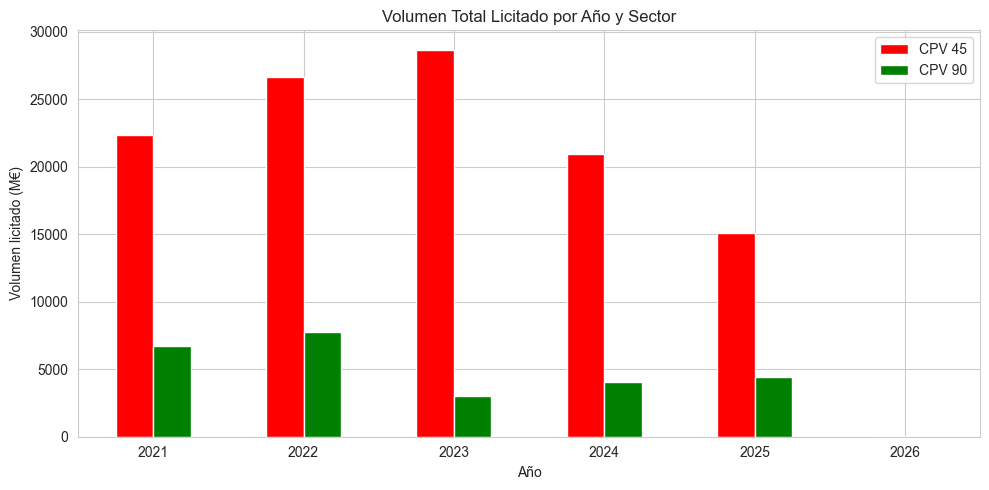

In [ ]:
vol_anual = (
    df[df['Año_Oferta'] >= 2021]
    .groupby(['Año_Oferta', 'CPV_Grupo'])['Presupuesto base sin impuestos']
    .sum()
    .div(1e6)
    .unstack('CPV_Grupo')
)

vol_anual.plot(kind='bar', figsize=(10, 5), color=['red', 'green'])
plt.title('Volumen Total Licitado por Año y Sector')
plt.xlabel('Año')
plt.ylabel('Volumen licitado (M€)')
plt.xticks(rotation=0)
plt.legend(['CPV 45', 'CPV 90'])
plt.tight_layout()
plt.show()

Vemos que el sector de la construcción suele tener mayores importes, con tendencia alcista hasta 2023 y cayendo hasta 2025.

En el sector de medio ambiente es parecido pero menores importes y hay una caída fuerte en 2023.

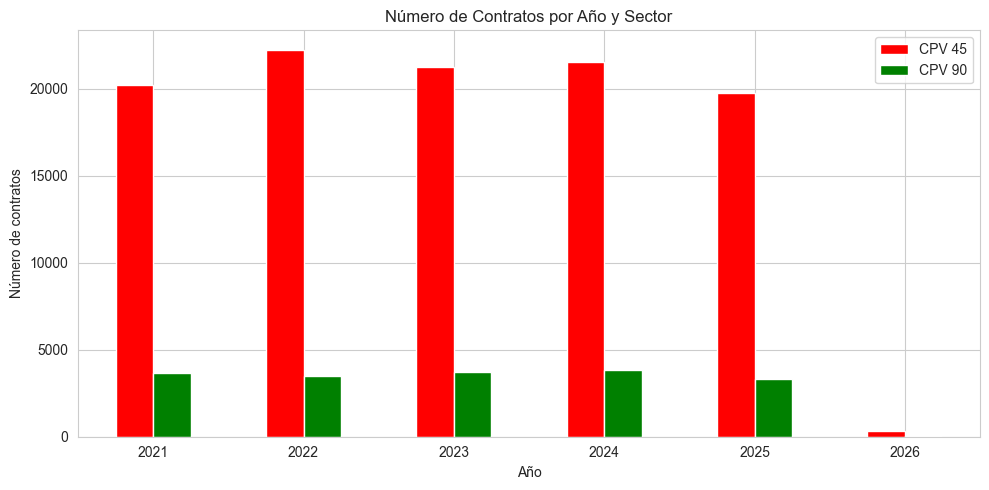

In [ ]:
contratos_anual = (
    df[df['Año_Oferta'] >= 2021]
    .groupby(['Año_Oferta', 'CPV_Grupo'])
    .size()
    .unstack('CPV_Grupo')
)

contratos_anual.plot(kind='bar', figsize=(10, 5), color=['red', 'green'])
plt.title('Número de Contratos por Año y Sector')
plt.xlabel('Año')
plt.ylabel('Número de contratos')
plt.xticks(rotation=0)
plt.legend(['CPV 45', 'CPV 90'])
plt.tight_layout()
plt.show()

De normal hay muchas más ofertas en construcción

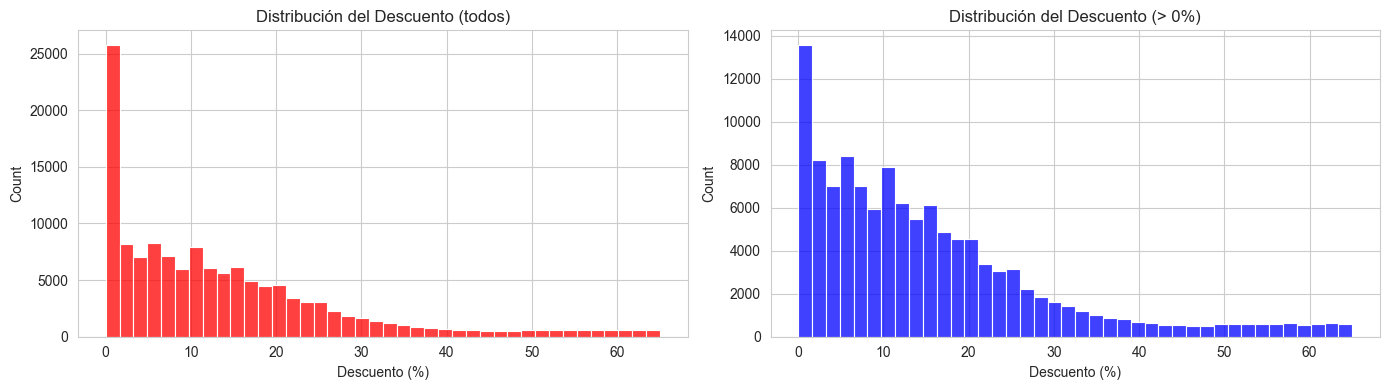

Contratos SIN descuento: 12234 (9.3%)


In [ ]:
# Distribución del target
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Todos los contratos
sns.histplot(df['Target_Descuento'], bins=40, ax=axes[0], color='red')
axes[0].set_title('Distribución del Descuento (todos)')
axes[0].set_xlabel('Descuento (%)')

# Solo contratos con competencia (descuento > 0)
sns.histplot(df[df['Target_Descuento'] > 0]['Target_Descuento'],
             bins=40, ax=axes[1], color='blue')
axes[1].set_title('Distribución del Descuento (> 0%)')
axes[1].set_xlabel('Descuento (%)')

plt.tight_layout()
plt.show()

print(f"Contratos SIN descuento: {(df['Target_Descuento'] == 0).sum()} "
      f"({(df['Target_Descuento'] == 0).mean()*100:.1f}%)")

Vemos que una gran cantidad de contratos no tienen descuento. Los que si tienen tienen una gran cantidad de descuentos bajos y menos descuentos elevados.

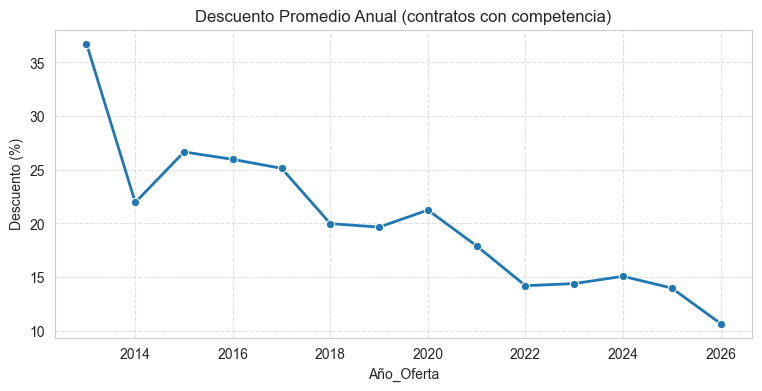

In [ ]:
# Tendencia anual del descuento medio
tendencia = df[df['Target_Descuento'] > 0].groupby('Año_Oferta')['Target_Descuento'].mean()

plt.figure(figsize=(9, 4))
sns.lineplot(x=tendencia.index, y=tendencia.values, marker='o', linewidth=2)
plt.title('Descuento Promedio Anual (contratos con competencia)')
plt.ylabel('Descuento (%)')
plt.xlabel('Año_Oferta')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Vemos que la tasa media de descuento está en una tendencia decreciente. ¿Menor competencia?

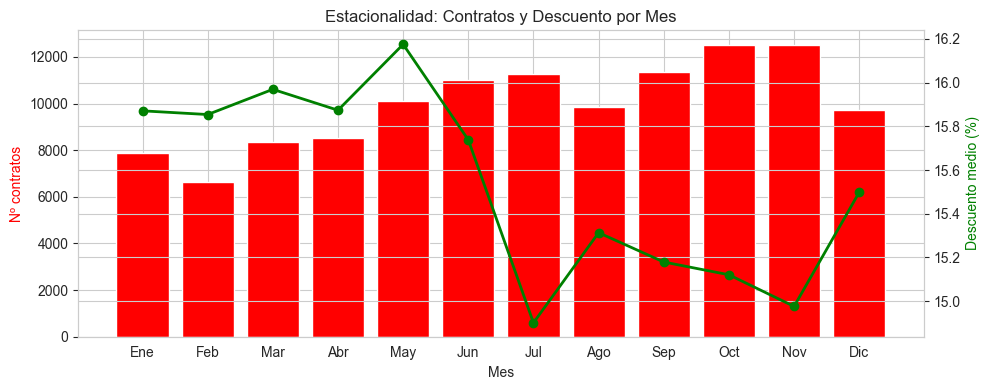

In [ ]:
# Estacionalidad Mensual
mes_resumen = (
    df[df['Target_Descuento'] > 0]
    .groupby('Mes_Oferta')['Target_Descuento']
    .agg(['mean', 'count'])
)

fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.bar(mes_resumen.index, mes_resumen['count'], color='red', label='Nº contratos')
ax1.set_ylabel('Nº contratos', color='red')
ax1.set_xlabel('Mes')

ax2 = ax1.twinx()
ax2.plot(mes_resumen.index, mes_resumen['mean'], color='green',
         marker='o', linewidth=2, label='Descuento medio')
ax2.set_ylabel('Descuento medio (%)', color='green')

ax1.set_title('Estacionalidad: Contratos y Descuento por Mes')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                      'Jul','Ago','Sep','Oct','Nov','Dic'])
plt.tight_layout()
plt.show()

La primera mitad de año hay menos contratos con una mayor tasa de descuento.

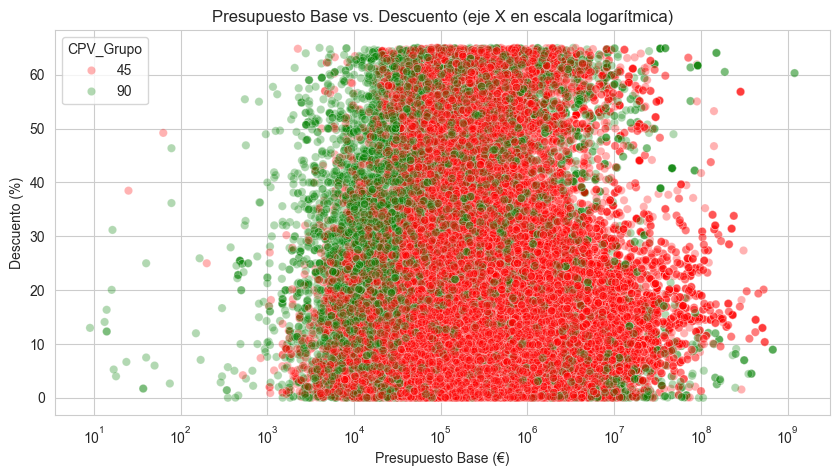

In [ ]:
# Presupuesto vs Descuento (escala log)
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df[df['Target_Descuento'] > 0],
    x='Presupuesto base sin impuestos', y='Target_Descuento', hue= 'CPV_Grupo', palette={'45':'red', '90':'green'},
    alpha=0.3
)
plt.xscale('log')
plt.title('Presupuesto Base vs. Descuento (eje X en escala logarítmica)')
plt.xlabel('Presupuesto Base (€)')
plt.ylabel('Descuento (%)')
plt.show()

No se ve una relación clara entre % de descuento y el tamaño del contrato

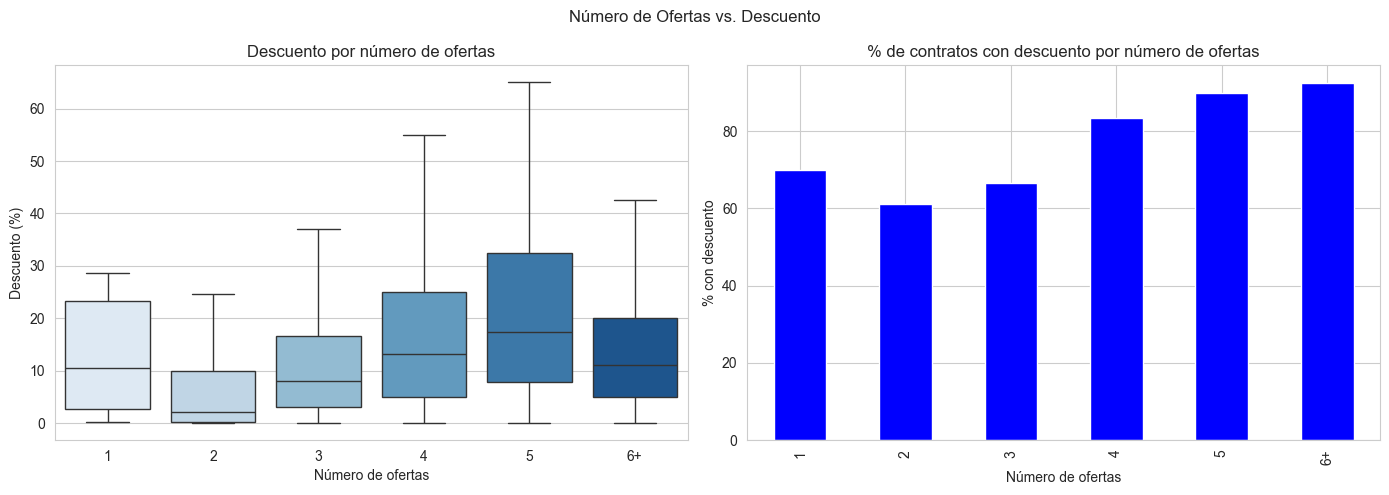

In [ ]:
# Recortar outliers y crear tramos
p95 = df['Ofertas_Historico'].quantile(0.95)
df_plot = df[df['Ofertas_Historico'] <= p95].copy()
df_plot['Tramo_Ofertas'] = pd.cut(
    df_plot['Ofertas_Historico'],
    bins=[0, 1, 2, 3, 4, 5, p95],
    labels=['1', '2', '3', '4', '5', f'6+'],
    right=True
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Número de Ofertas vs. Descuento')

# Boxplot descuento por tramo (solo contratos con descuento)
sns.boxplot(
    data=df_plot[df_plot['Target_Descuento'] > 0],
    x='Tramo_Ofertas', y='Target_Descuento',
    palette='Blues', showfliers=False, ax=axes[0]
)
axes[0].set_title('Descuento por número de ofertas')
axes[0].set_xlabel('Número de ofertas')
axes[0].set_ylabel('Descuento (%)')

# Barras % de contratos con descuento
tasa = df_plot.groupby('Tramo_Ofertas', observed=False)['Hay_Descuento'].mean() * 100
tasa.plot(kind='bar', ax=axes[1], color='blue')
axes[1].set_title('% de contratos con descuento por número de ofertas')
axes[1].set_xlabel('Número de ofertas')
axes[1].set_ylabel('% con descuento')

plt.tight_layout()
plt.show()

Se observa que a media que se reciben más ofertas el descuento medio aumenta, excluyendo los outliers (>percentil 95). También aumenta el número de contratos con descuento.

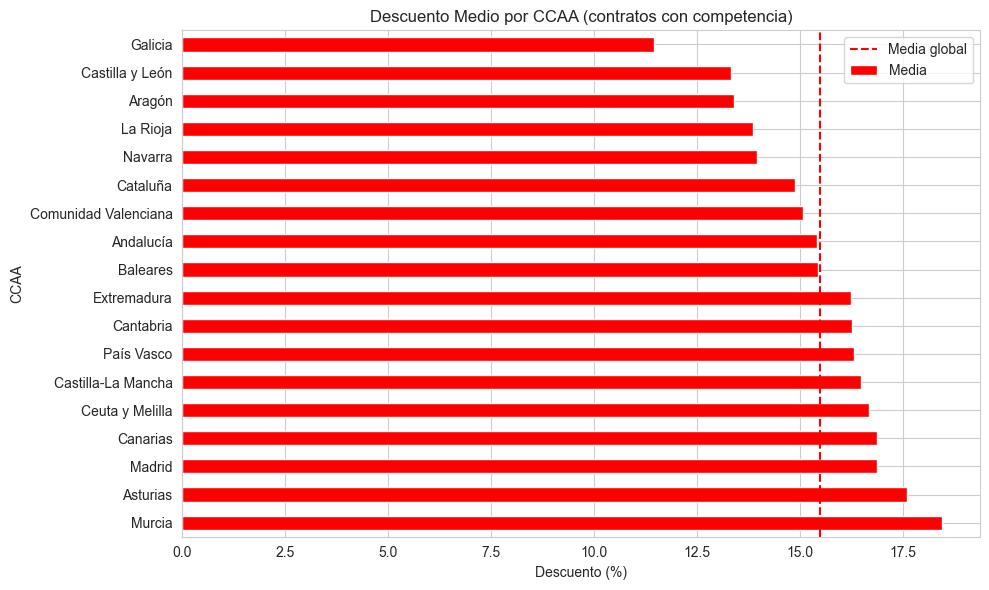

                      Media  Mediana      N
CCAA                                       
Murcia                18.45    16.36   3568
Asturias              17.60    14.87   3555
Madrid                16.88    13.34  25467
Canarias              16.87    12.33   7724
Ceuta y Melilla       16.68    15.88    878
Castilla-La Mancha    16.49    12.54   6738
País Vasco            16.32    13.27    481
Cantabria             16.26    14.00   2183
Extremadura           16.25    11.98   4558
Baleares              15.44    11.76   4528
Andalucía             15.42    12.42  19460
Comunidad Valenciana  15.08    10.85  13926
Cataluña              14.89    11.64   1380
Navarra               13.96    13.16     58
La Rioja              13.86    10.38   1112
Aragón                13.40     9.40   6082
Castilla y León       13.33    10.15   9222
Galicia               11.45     8.05   8772


In [ ]:
# Descuento por CCAA
ccaa_resumen = (
    df[df['Target_Descuento'] > 0]
    .groupby('CCAA')['Target_Descuento']
    .agg(['mean', 'median', 'count'])
    .rename(columns={'mean': 'Media', 'median': 'Mediana', 'count': 'N'})
    .sort_values('Media', ascending=False)
    .round(2)
)

fig, ax = plt.subplots(figsize=(10, 6))
ccaa_resumen['Media'].plot(kind='barh', ax=ax, color='red')
ax.set_title('Descuento Medio por CCAA (contratos con competencia)')
ax.set_xlabel('Descuento (%)')
ax.axvline(df[df['Target_Descuento'] > 0]['Target_Descuento'].mean(),
           color='red', linestyle='--', label='Media global')
ax.legend()
plt.tight_layout()
plt.show()

print(ccaa_resumen)

Murcia, Asturias y Madrid tienen una mayor competencia en descuento. Galicia y CyL tienen menores competencias.

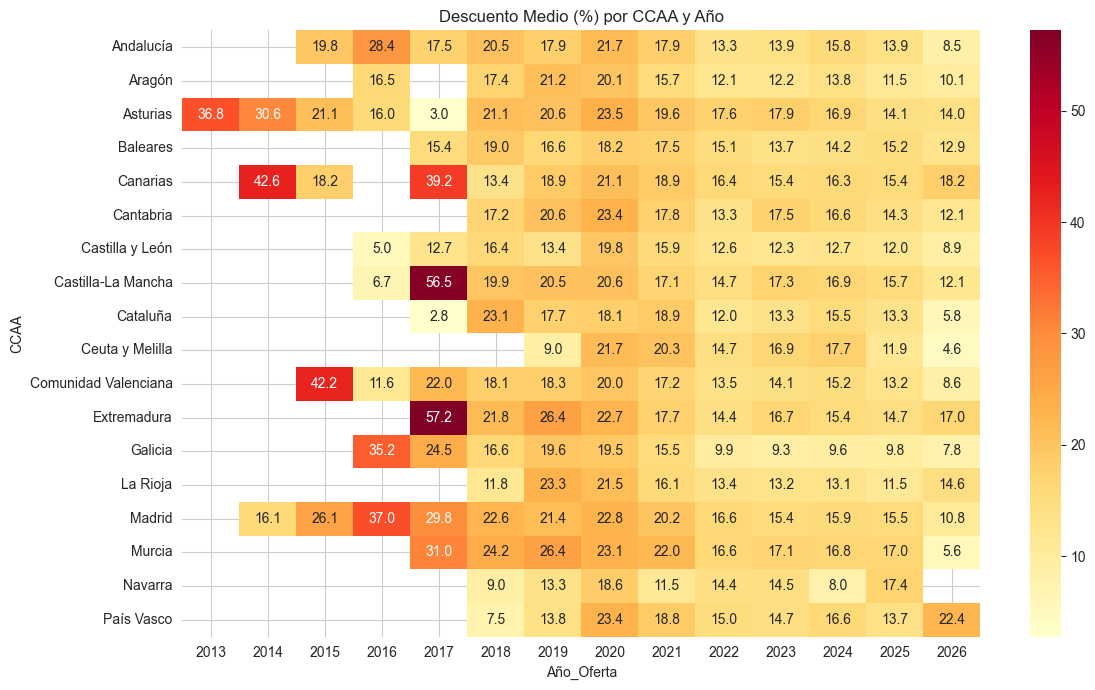

In [ ]:
pivot_ccaa_año = (
    df[df['Target_Descuento'] > 0]
    .groupby(['CCAA', 'Año_Oferta'])['Target_Descuento']
    .mean()
    .round(1)
    .unstack('Año_Oferta')
)

plt.figure(figsize=(12, 7))
sns.heatmap(pivot_ccaa_año, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Descuento Medio (%) por CCAA y Año')
plt.tight_layout()
plt.show()

Vemos como por lo general los descuentos están cayendo.

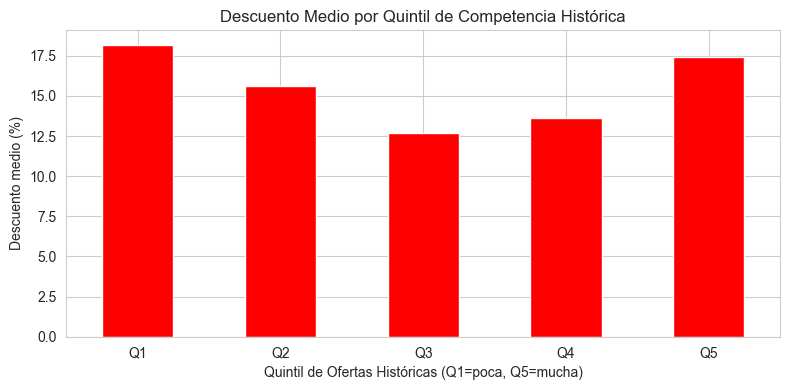

In [ ]:
df['Quintil_Ofertas'] = pd.qcut(df['Ofertas_Historico'], q=5, labels=['Q1','Q2','Q3','Q4','Q5'])

(df[df['Target_Descuento'] > 0]
 .groupby('Quintil_Ofertas')['Target_Descuento']
 .mean()
 .plot(kind='bar', figsize=(8, 4), color='red'))

plt.title('Descuento Medio por Quintil de Competencia Histórica')
plt.xlabel('Quintil de Ofertas Históricas (Q1=poca, Q5=mucha)')
plt.ylabel('Descuento medio (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df = df.drop(columns=['Quintil_Ofertas'])

Hay mayores tasas de descuento en proyectos sin competencia (libertad de bajar el precio porque eres el único) y los de mucha competencia (necesidad de descontar para ganarla)

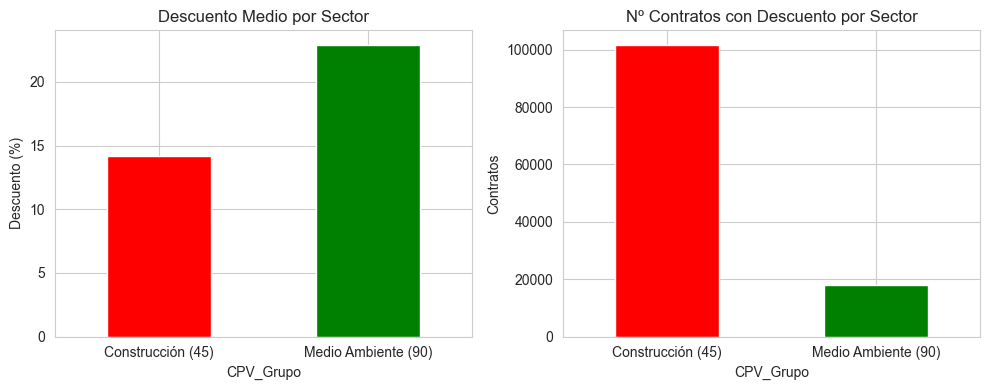

In [ ]:
resumen_sector = (
    df[df['Target_Descuento'] > 0]
    .groupby('CPV_Grupo')['Target_Descuento']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Descuento_Medio', 'count': 'N'})
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Descuento medio por sector
resumen_sector['Descuento_Medio'].plot(kind='bar', ax=axes[0], color=['red', 'green'])
axes[0].set_title('Descuento Medio por Sector')
axes[0].set_ylabel('Descuento (%)')
axes[0].set_xticklabels(['Construcción (45)', 'Medio Ambiente (90)'], rotation=0)

# Número de contratos por sector
resumen_sector['N'].plot(kind='bar', ax=axes[1], color=['red', 'green'])
axes[1].set_title('Nº Contratos con Descuento por Sector')
axes[1].set_ylabel('Contratos')
axes[1].set_xticklabels(['Construcción (45)', 'Medio Ambiente (90)'], rotation=0)

plt.tight_layout()
plt.show()

Aunque hay menos contratos con descuento en Medio Ambiente, cuando sí tienen descuento suelen ser superiores a los de Construcción.

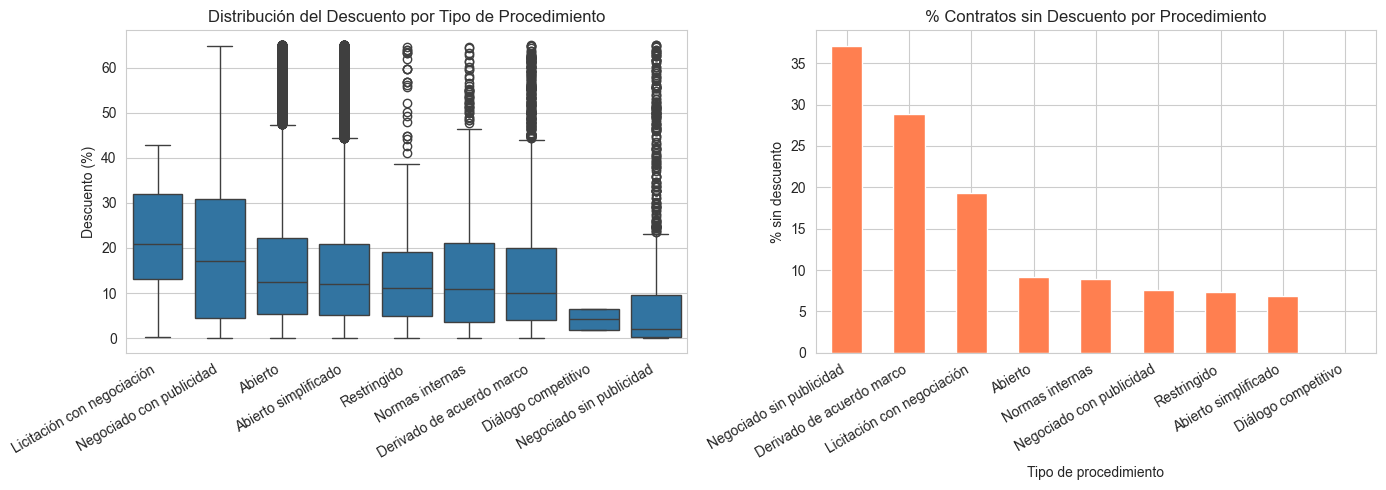

In [ ]:
proc_col = 'Tipo de procedimiento'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot de descuento por procedimiento
orden = (df[df['Target_Descuento'] > 0]
         .groupby(proc_col)['Target_Descuento']
         .median()
         .sort_values(ascending=False)
         .index)

sns.boxplot(
    data=df[df['Target_Descuento'] > 0],
    x=proc_col, y='Target_Descuento',
    order=orden, ax=axes[0]
)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].set_title('Distribución del Descuento por Tipo de Procedimiento')
axes[0].set_ylabel('Descuento (%)')
axes[0].set_xlabel('')

# % de contratos sin descuento por procedimiento
tasa_cero = df.groupby(proc_col).apply(
    lambda x: (x['Target_Descuento'] == 0).mean() * 100
).sort_values(ascending=False)

tasa_cero.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('% Contratos sin Descuento por Procedimiento')
axes[1].set_ylabel('% sin descuento')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

Por tipo de procedimiento, los que no incluyen acuerdos, preselecciones o negociaciones directas suelen tener más descuento.

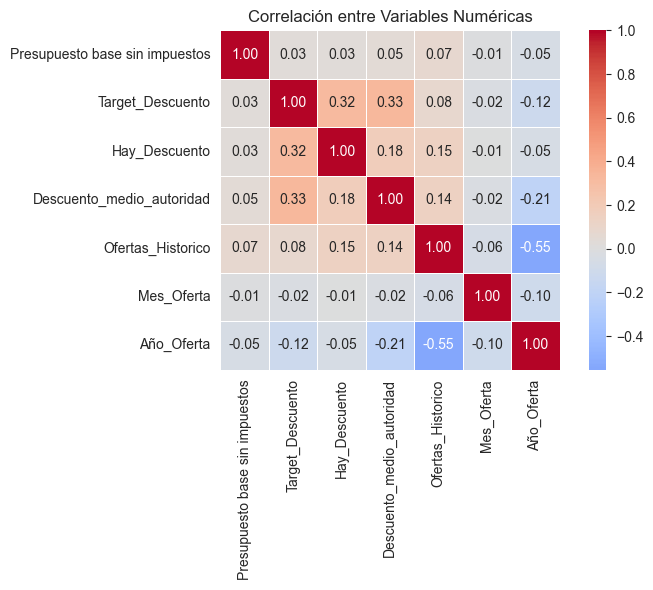

In [ ]:
# Matriz correlación
# Numéricas más relevantes
cols_num = [
    'Presupuesto base sin impuestos',
    'Target_Descuento',
    'Hay_Descuento',
    'Descuento_medio_autoridad',
    'Ofertas_Historico',
    'Mes_Oferta',
    'Año_Oferta'
]
cols_num = [c for c in cols_num if c in df.columns]  # solo las que existan

corr = df[cols_num].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlación entre Variables Numéricas')
plt.tight_layout()
plt.show()

Se ve como a medida que pasan los años el descuento baja. También que el descuento histórico de la autoridad está relacionado con el descuento futuro. En el resto las correlaciones son bajas.

## One-Hot Encoding. El EDA tiene que ir antes para poder usar las variables originales

In [ ]:
# One-Hot Encoding de variables categóricas restantes
columnas_categoricas = [
    'Tipo de contrato', 'Tipo de procedimiento', 'Sistema de contratación',
    'Tramitación', 'Forma de presentación de la oferta',
    'Directiva de aplicación', 'Contrato SARA/Umbral',
    'Financiación Europea y fuente', 'Subasta electrónica', 'CCAA'
]
df = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)

In [ ]:
print(f"Shape final del dataset: {df.shape}")
df.head(3)

Shape final del dataset: (131926, 104)


,Presupuesto base sin impuestos,Target_Descuento,Hay_Descuento,Mes_Oferta,Año_Oferta,CPV_Grupo,Admin_Local,Admin_Regional,Admin_Estatal,Admin_Org_Publico,...,CCAA_Cataluña,CCAA_Ceuta y Melilla,CCAA_Comunidad Valenciana,CCAA_Extremadura,CCAA_Galicia,CCAA_La Rioja,CCAA_Madrid,CCAA_Murcia,CCAA_Navarra,CCAA_País Vasco
1326716,39999.00,0.00,0,11,1981,45,0,0,1,0,...,False,False,False,False,True,False,False,False,False,False
1116998,289921.54,33.47,1,10,2013,45,0,0,1,0,...,False,False,False,False,False,False,False,False,False,False
1116918,232529.36,40.04,1,11,2013,45,0,0,1,0,...,False,False,False,False,False,False,False,False,False,False


# 5 Explicativo

## 5.1 Regresión Logística

In [ ]:
import statsmodels.api as sm

# Submuestra: todos los contratos (no solo los que tienen descuento)
df_logit = df.copy()

# Mismas variables que el OLS
formula_logit = (
    'Hay_Descuento ~ '
    'np.log1p(Q("Presupuesto base sin impuestos")) + '
    'Mes_Oferta + '
    'Año_Oferta + '
    'Descuento_medio_autoridad + '
    'Ofertas_Historico + '
    'Q("Tipo de procedimiento_Abierto simplificado") + '
    'Q("Tipo de procedimiento_Negociado sin publicidad") + '
    'Q("Tipo de procedimiento_Negociado con publicidad") + '
    'Q("Contrato SARA/Umbral_Sí") + '
    'Q("Financiación Europea y fuente_Si") + '
    'Q("Tramitación_Urgente") + '
    'Q("Tipo de contrato_Obras") + '
    'Q("Tipo de contrato_Servicios") + '
    'Admin_Local + Admin_Regional + Admin_Estatal + Admin_Org_Publico + '
    'CCAA_Madrid + '
    'Q("CCAA_Cataluña") + '
    'Q("CCAA_Comunidad Valenciana") + '
    'Q("CCAA_Castilla y León") + '
    'C(CPV_Grupo)'
)

modelo_logit = smf.logit(formula=formula_logit, data=df_logit).fit()
print(modelo_logit.summary())

Optimization terminated successfully.
         Current function value: 0.261920
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:          Hay_Descuento   No. Observations:               131926
Model:                          Logit   Df Residuals:                   131903
Method:                           MLE   Df Model:                           22
Date:                Wed, 10 Jun 2026   Pseudo R-squ.:                  0.1519
Time:                        21:11:53   Log-Likelihood:                -34554.
converged:                       True   LL-Null:                       -40741.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------
Intercept 

El modelo logístico explicativo muestra que la probabilidad de que una licitación genere descuento está determinada principalmente por tres factores: la competencia esperada (medida tanto por el histórico de ofertas como por el tipo de procedimiento), el tamaño del contrato (a mayor presupuesto, mayor competencia) y el comportamiento histórico del órgano de contratación (los organismos que han generado descuento en el pasado tienden a seguir haciéndolo). El resultado más destacado es el fuerte efecto negativo de Madrid (-1.01) y del procedimiento negociado sin publicidad (-1.07), lo que sugiere que este mercado y la restricción artificial de la competencia son los principales inhibidores del descuento, por encima incluso del sector o el tipo de contrato. El R² de 0.15, es considerado bueno para este tipo de trabajos, ya que confirma que el descuento no es aleatorio, sino que responde a variables observables antes de la resolución del contrato, lo que abre la puerta a su predicción.

## 5.2 OLS

Usamos OLS sobre la submuestra con descuento > 0 para interpretar qué variables están estadísticamente asociadas con el nivel de descuento.

In [ ]:
# Submuestra: solo contratos en los que hay competencia real
df_exp = df[df['Target_Descuento'] > 0].copy()

formula = (
    'Target_Descuento ~ '
    'np.log1p(Q("Presupuesto base sin impuestos")) + '
    'Mes_Oferta + '
    'Año_Oferta +'
    'Descuento_medio_autoridad + '
    'Ofertas_Historico +'
    'Q("Tipo de procedimiento_Abierto simplificado") + '
    'Q("Tipo de procedimiento_Negociado sin publicidad") + '
    'Q("Tipo de procedimiento_Negociado con publicidad") + '
    'Q("Contrato SARA/Umbral_Sí") + '
    'Q("Financiación Europea y fuente_Si") + '
    'Q("Tramitación_Urgente") + '
    'Q("Tipo de contrato_Obras") + '
    'Q("Tipo de contrato_Servicios") + '
    'Admin_Local + Admin_Regional + Admin_Estatal + Admin_Org_Publico + '
    'CCAA_Madrid + '
    'Q("CCAA_Cataluña") + '
    'Q("CCAA_Comunidad Valenciana") + '
    'Q("CCAA_Castilla y León") +'
    '+ C(CPV_Grupo)'
)

modelo_exp = smf.ols(formula=formula, data=df_exp).fit()
print(modelo_exp.summary())

                            OLS Regression Results                            
Dep. Variable:       Target_Descuento   R-squared:                       0.144
Model:                            OLS   Adj. R-squared:                  0.144
Method:                 Least Squares   F-statistic:                     916.9
Date:                Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:11:54   Log-Likelihood:            -4.7756e+05
No. Observations:              119692   AIC:                         9.552e+05
Df Residuals:                  119669   BIC:                         9.554e+05
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                                                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

Vemos un R2 de 0.144, de nuevo razonable para un problema tan complejo y usando datos reales. El F-statistic es muy elevado y tiene p = 0.00, lo que indica que es un modelo altamente significativo.

Una vez hay descuento, la magnitud se explica por la inercia de cada órgano (cada punto de descuento histórico se traslada a casi 0.5 puntos adicionales de descuento) y la presión competitiva histórica por segmento CPV o procedimiento (+0.64 puntos).

El sector Medio Ambiente descuenta casi 5 puntos más que constrcción, algo que ya habíamos comprobado en el EDA.

Algo relevante se ve en Madrid. En la regresión logística se veía que tenia menor probabilidad de descuento, pero cuando lo hay, es mayor que la media nacional. Esto parece indicar que es un mercado concentrado donde al aparecer competencia es muy agresiva.

## 5.3 Decision Tree

In [ ]:
# Usamos las mismas variables que en el OLS
cols_tree = [
    'Presupuesto base sin impuestos',
    'Mes_Oferta',
    'Descuento_medio_autoridad',
    'Ofertas_Historico',
    'Año_Oferta',
    'Admin_Local', 'Admin_Regional', 'Admin_Estatal', 'Admin_Org_Publico',
]
# Añadir las dummies que vienen del get_dummies
cols_dummies = [c for c in df.columns if any(c.startswith(p) for p in [
    'Tipo de procedimiento_', 'Tipo de contrato_', 'Tramitación_',
    'Contrato SARA', 'Financiación Europea', 'CCAA_'
])]

X_exp = df_exp[cols_tree + cols_dummies].fillna(0)
y_exp = df_exp['Target_Descuento']

# Árbol poco profundo: interpretable, no sobreajustado
tree_exp = DecisionTreeRegressor(max_depth=4, min_samples_leaf=30, random_state=42)
tree_exp.fit(X_exp, y_exp)

print(f"R² en train: {tree_exp.score(X_exp, y_exp):.3f}")

R² en train: 0.136


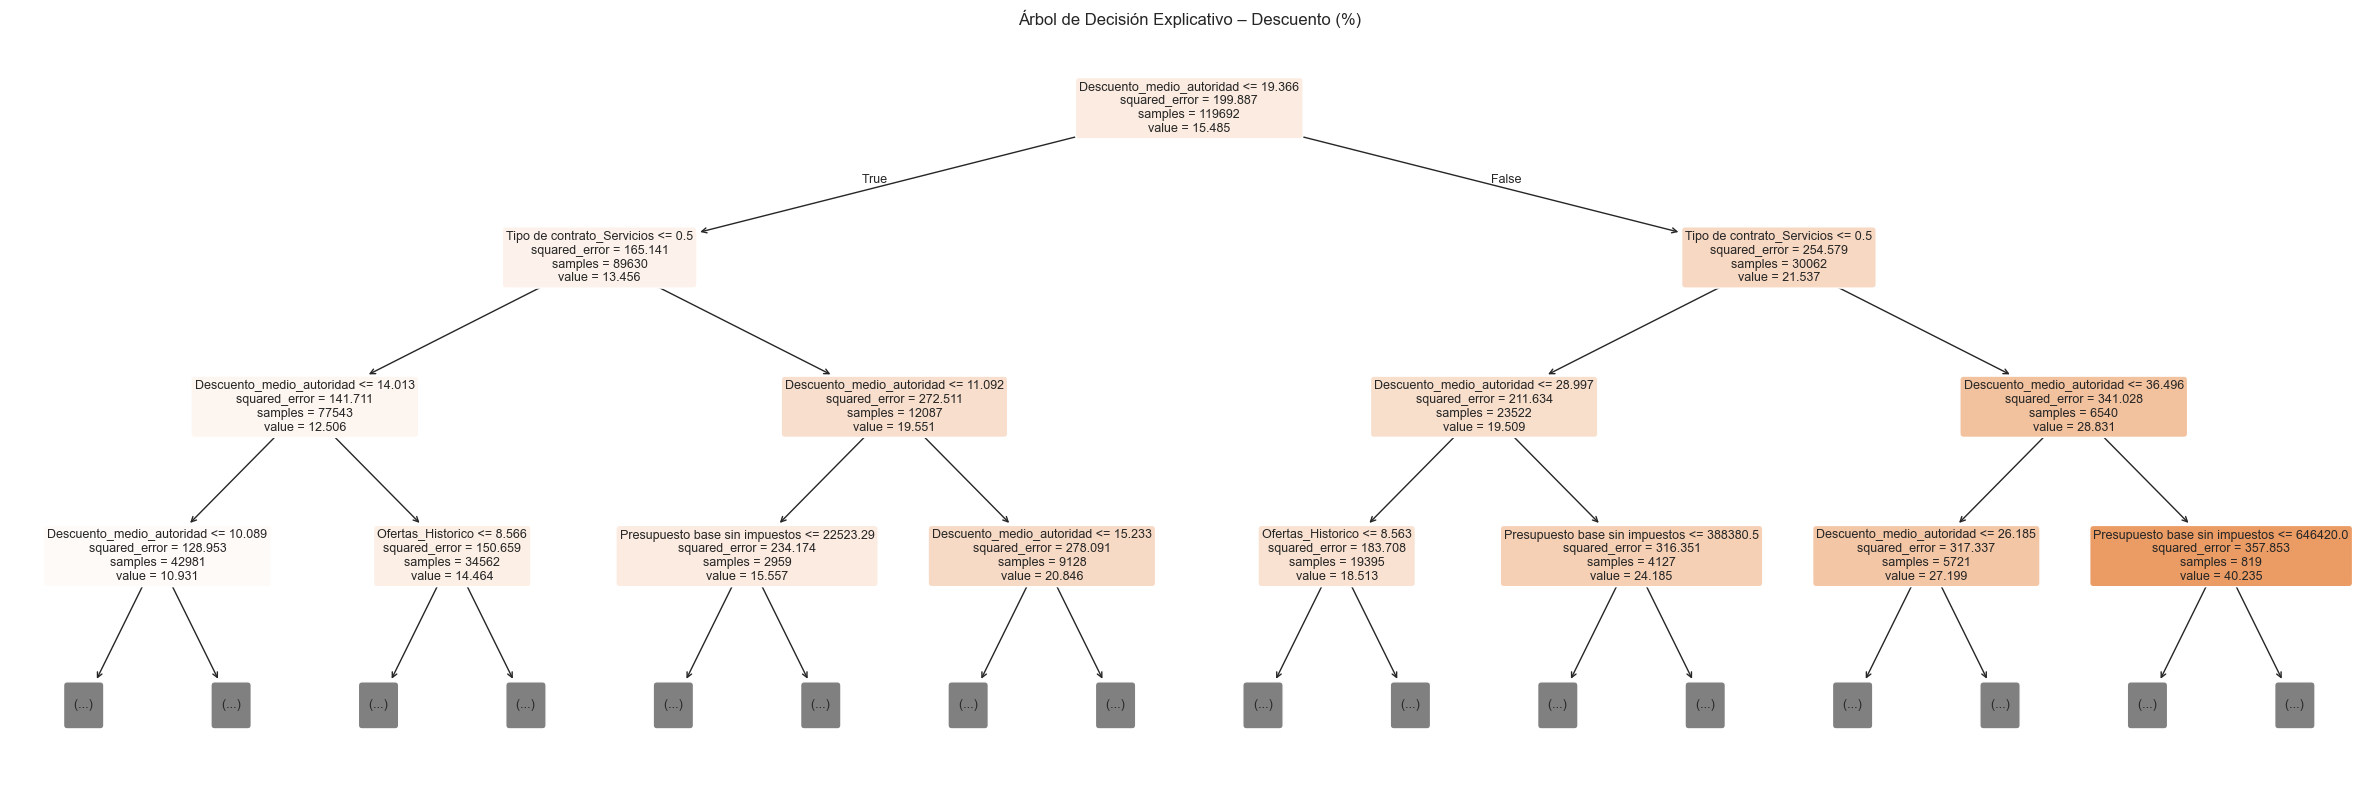

In [ ]:
plt.figure(figsize=(24, 8))
plot_tree(
    tree_exp,
    feature_names=X_exp.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3
)
plt.title('Árbol de Decisión Explicativo – Descuento (%)')
plt.tight_layout()
plt.show()

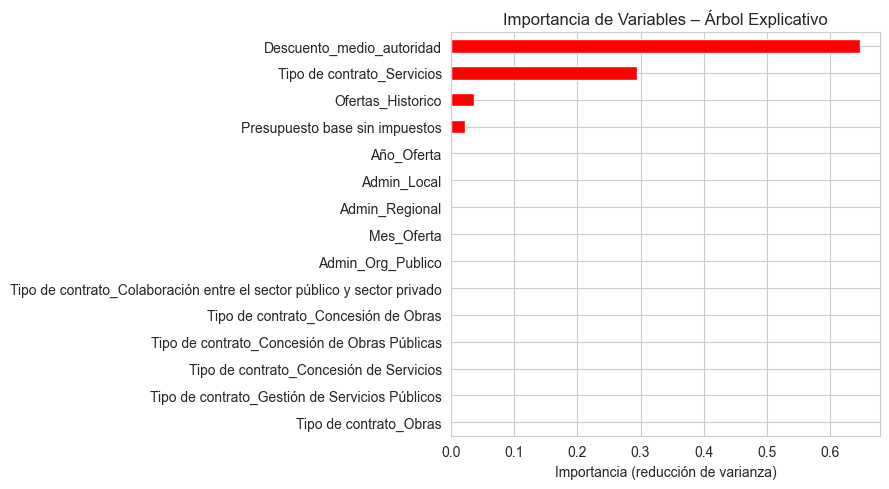

In [ ]:
importancias = (
    pd.Series(tree_exp.feature_importances_, index=X_exp.columns)
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(9, 5))
importancias.plot(kind='barh', color='red')
plt.gca().invert_yaxis()
plt.title('Importancia de Variables – Árbol Explicativo')
plt.xlabel('Importancia (reducción de varianza)')
plt.tight_layout()
plt.show()

La variable más determinante vemos de nuevo que es 'Descuento_medio_autoridad'. Luego, el tipo de contratos (servicios condescuentos más altos).
Ofertas_histórico y presupuesto tienen importancia baja, el resto son irrelevantes para el árbol.

# 6 Modelo Predictivo
Primero con construcción

In [ ]:
df_co = df[df['CPV_Grupo'] == SECTOR ].copy()

print(f"Registros Construcción: {len(df_co)}")
print(df_co['Target_Descuento'].describe())

Registros Construcción: 20193
count    20193.000000
mean        20.492065
std         18.237504
min          0.000000
25%          5.010000
50%         16.120000
75%         31.360000
max         65.000000
Name: Target_Descuento, dtype: float64


## Split cronológico 80/20

Usamos split por tiempo en lugar de aleatorio para evitar data leakage: el modelo solo puede saber lo que sabría en el momento de la licitación.

In [ ]:
# Ordenar cronológicamente
df_co = df_co.sort_values('Año_Oferta')

# Corte en el 80% de las filas
corte = int(len(df_co) * 0.80)
df_train_co = df_co.iloc[:corte]
df_test_co  = df_co.iloc[corte:]

print(f"Train: {len(df_train_co)} registros | Años: {df_train_co['Año_Oferta'].min()}–{df_train_co['Año_Oferta'].max()}")
print(f"Test:  {len(df_test_co)} registros  | Años: {df_test_co['Año_Oferta'].min()}–{df_test_co['Año_Oferta'].max()}")

Train: 16154 registros | Años: 2014–2024
Test:  4039 registros  | Años: 2024–2026


# 6.1 Clasificador

In [ ]:
# Separar features X y target y
# Excluimos columnas que ya no aportan información al modelo
cols_excluir = ['Target_Descuento', 'Hay_Descuento', 'Año_Oferta', 'CPV_Grupo']

X_train_co = df_train_co.drop(columns=cols_excluir, errors='ignore')
y_train_co = df_train_co['Hay_Descuento']

X_test_co = df_test_co.drop(columns=cols_excluir, errors='ignore')
y_test_co = df_test_co['Hay_Descuento']

print(f"Train: {len(df_train_co)} registros | Test: {len(df_test_co)} registros")

Train: 16154 registros | Test: 4039 registros


## 6.1.1 Baseline

In [ ]:
# Clase mayoritaria en el train
clase_mayoritaria = y_train_co.mode()[0]
y_pred_baseline = np.full(len(y_test_co), clase_mayoritaria)

accuracy_baseline = (y_pred_baseline == y_test_co).mean()
print(f"Clase mayoritaria: {clase_mayoritaria}")
print(f"Accuracy Baseline: {accuracy_baseline*100:.1f}%")

Clase mayoritaria: 1
Accuracy Baseline: 87.7%


En un modelo baseline, vemos que casi el 90% de los contratos tiene algo de descuento.
En los modelos usaremos class_weight=balanced para que el modelo no ignore los contratos sin descuento.

## 6.1.2 Regresión Logística

In [ ]:
from sklearn.linear_model import LogisticRegression

pipeline_lr = Pipeline([
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

param_distribution = {
    'model__C': [0.01, 0.1, 1, 10, 100]
}

random_search_lr = RandomizedSearchCV(
    estimator=pipeline_lr,
    param_distributions=param_distribution,
    n_iter=5,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_lr.fit(X_train_co, y_train_co)

best_lr = random_search_lr.best_estimator_
print("Best params:", random_search_lr.best_params_)
print(f"Best CV ROC-AUC: {random_search_lr.best_score_:.4f}")

y_pred_lr_clf       = best_lr.predict(X_test_co)
y_pred_proba_lr_clf = best_lr.predict_proba(X_test_co)[:, 1]

print("=== Regresión Logística ===")
print(classification_report(y_test_co, y_pred_lr_clf, target_names=['Sin descuento', 'Con descuento']))
print(f"AUC-ROC: {roc_auc_score(y_test_co, y_pred_proba_lr_clf):.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params: {'model__C': 10}
Best CV ROC-AUC: 0.6108
=== Regresión Logística ===
               precision    recall  f1-score   support

Sin descuento       0.19      0.66      0.30       495
Con descuento       0.93      0.62      0.74      3544

     accuracy                           0.62      4039
    macro avg       0.56      0.64      0.52      4039
 weighted avg       0.84      0.62      0.69      4039

AUC-ROC: 0.6909


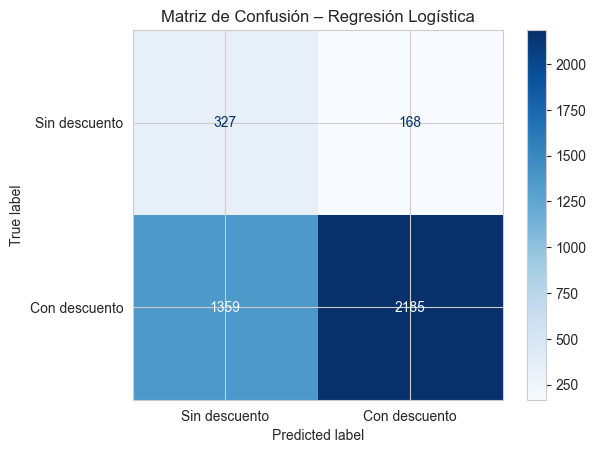

In [ ]:
cm = confusion_matrix(y_test_co, y_pred_lr_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Sin descuento', 'Con descuento'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión – Regresión Logística')
plt.show()

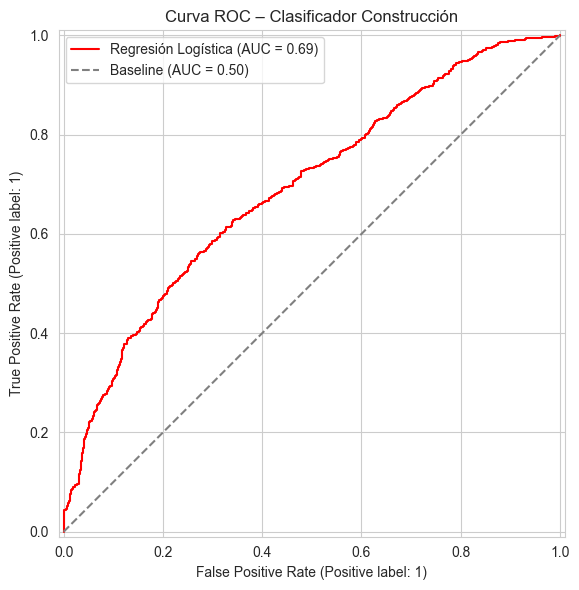

In [ ]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test_co,
    y_pred_proba_lr_clf,
    name='Regresión Logística',
    color='red',
    ax=ax
)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Baseline (AUC = 0.50)')
ax.set_title('Curva ROC – Clasificador Construcción')
ax.legend()
plt.tight_layout()
plt.show()

El modelo alcanza un AUC_ROC de 0.7, confirmando capacidad para discriminar entre contratos con y sin descuento. Cabe destacar que la precisión es algo más baja porque está compensando el desbalance de clases y aun así logra detectar el 66% de los contratos sin descuento a cambio de una precisión del 20% en esa clase.

Esto es relevante porque es más costoso ignorar un contrato sin competencia (océano azul) que generar falsas alarmas.

## 6.1.3 KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

param_distribution = {
    'model__n_neighbors': [5, 10, 15, 25, 50]
}

random_search_knn = RandomizedSearchCV(
    estimator=pipeline_knn,
    param_distributions=param_distribution,
    n_iter=5,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_knn.fit(X_train_co, y_train_co)

best_knn = random_search_knn.best_estimator_
print("Best params:", random_search_knn.best_params_)
print(f"Best CV ROC-AUC: {random_search_knn.best_score_:.4f}")

y_pred_knn_clf       = best_knn.predict(X_test_co)
y_pred_proba_knn_clf = best_knn.predict_proba(X_test_co)[:, 1]

print("=== KNN Clasificador ===")
print(classification_report(y_test_co, y_pred_knn_clf, target_names=['Sin descuento', 'Con descuento']))
print(f"AUC-ROC: {roc_auc_score(y_test_co, y_pred_proba_knn_clf):.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params: {'model__n_neighbors': 25}
Best CV ROC-AUC: 0.5859
=== KNN Clasificador ===
               precision    recall  f1-score   support

Sin descuento       0.88      0.03      0.06       495
Con descuento       0.88      1.00      0.94      3544

     accuracy                           0.88      4039
    macro avg       0.88      0.51      0.50      4039
 weighted avg       0.88      0.88      0.83      4039

AUC-ROC: 0.6213


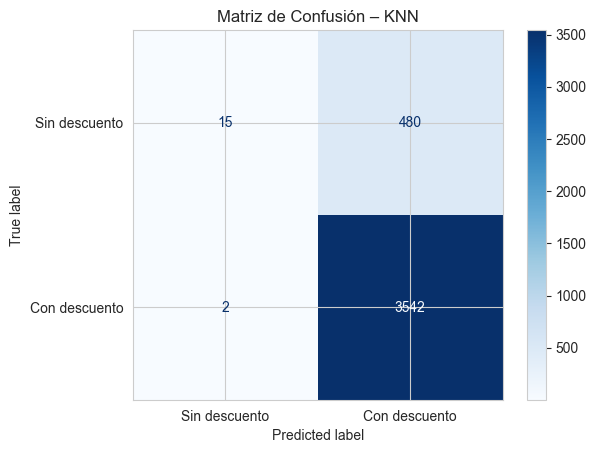

In [ ]:
cm = confusion_matrix(y_test_co, y_pred_knn_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Sin descuento', 'Con descuento'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión – KNN')
plt.show()

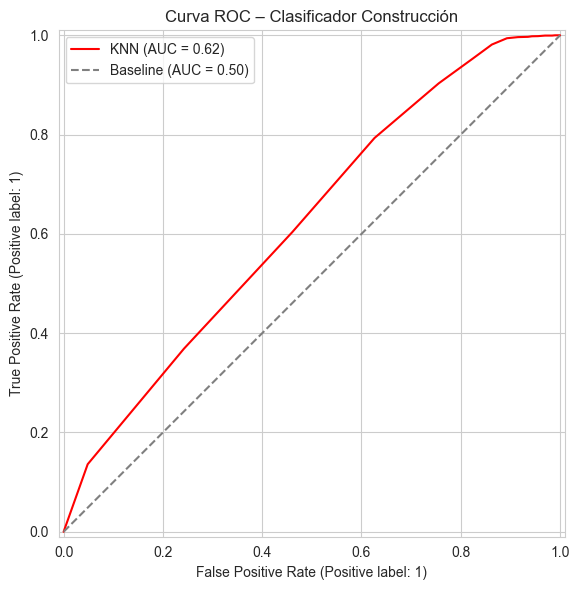

In [ ]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test_co,
    y_pred_proba_knn_clf,
    name='KNN',
    color='red',
    ax=ax
)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Baseline (AUC = 0.50)')
ax.set_title('Curva ROC – Clasificador Construcción')
ax.legend()
plt.tight_layout()
plt.show()

Resultado algo peor que la regresión logística (0.62 vs 0.8). El número óptimo de vecinos es 50, muy alto lo que indica que las clases no están muy bien definidas. Este modelo no ayuda mucho ya que solo tiene un recall de 0.03 en contratos sin descuento.

## 6.1.4 Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

pipeline_dt = Pipeline([
    ('model', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])

param_distribution = {
    'model__max_depth':        [3, 4, 6, 8, 10],
    'model__min_samples_leaf': [10, 20, 30, 50]
}

random_search_dt = RandomizedSearchCV(
    estimator=pipeline_dt,
    param_distributions=param_distribution,
    n_iter=10,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_dt.fit(X_train_co, y_train_co)

best_dt = random_search_dt.best_estimator_
print("Best params:", random_search_dt.best_params_)
print(f"Best CV ROC-AUC: {random_search_dt.best_score_:.4f}")

y_pred_dt_clf       = best_dt.predict(X_test_co)
y_pred_proba_dt_clf = best_dt.predict_proba(X_test_co)[:, 1]

print("=== Decision Tree Clasificador ===")
print(classification_report(y_test_co, y_pred_dt_clf, target_names=['Sin descuento', 'Con descuento']))
print(f"AUC-ROC: {roc_auc_score(y_test_co, y_pred_proba_dt_clf):.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'model__min_samples_leaf': 10, 'model__max_depth': 6}
Best CV ROC-AUC: 0.6223
=== Decision Tree Clasificador ===
               precision    recall  f1-score   support

Sin descuento       0.18      0.64      0.28       495
Con descuento       0.92      0.59      0.72      3544

     accuracy                           0.60      4039
    macro avg       0.55      0.61      0.50      4039
 weighted avg       0.83      0.60      0.67      4039

AUC-ROC: 0.6559


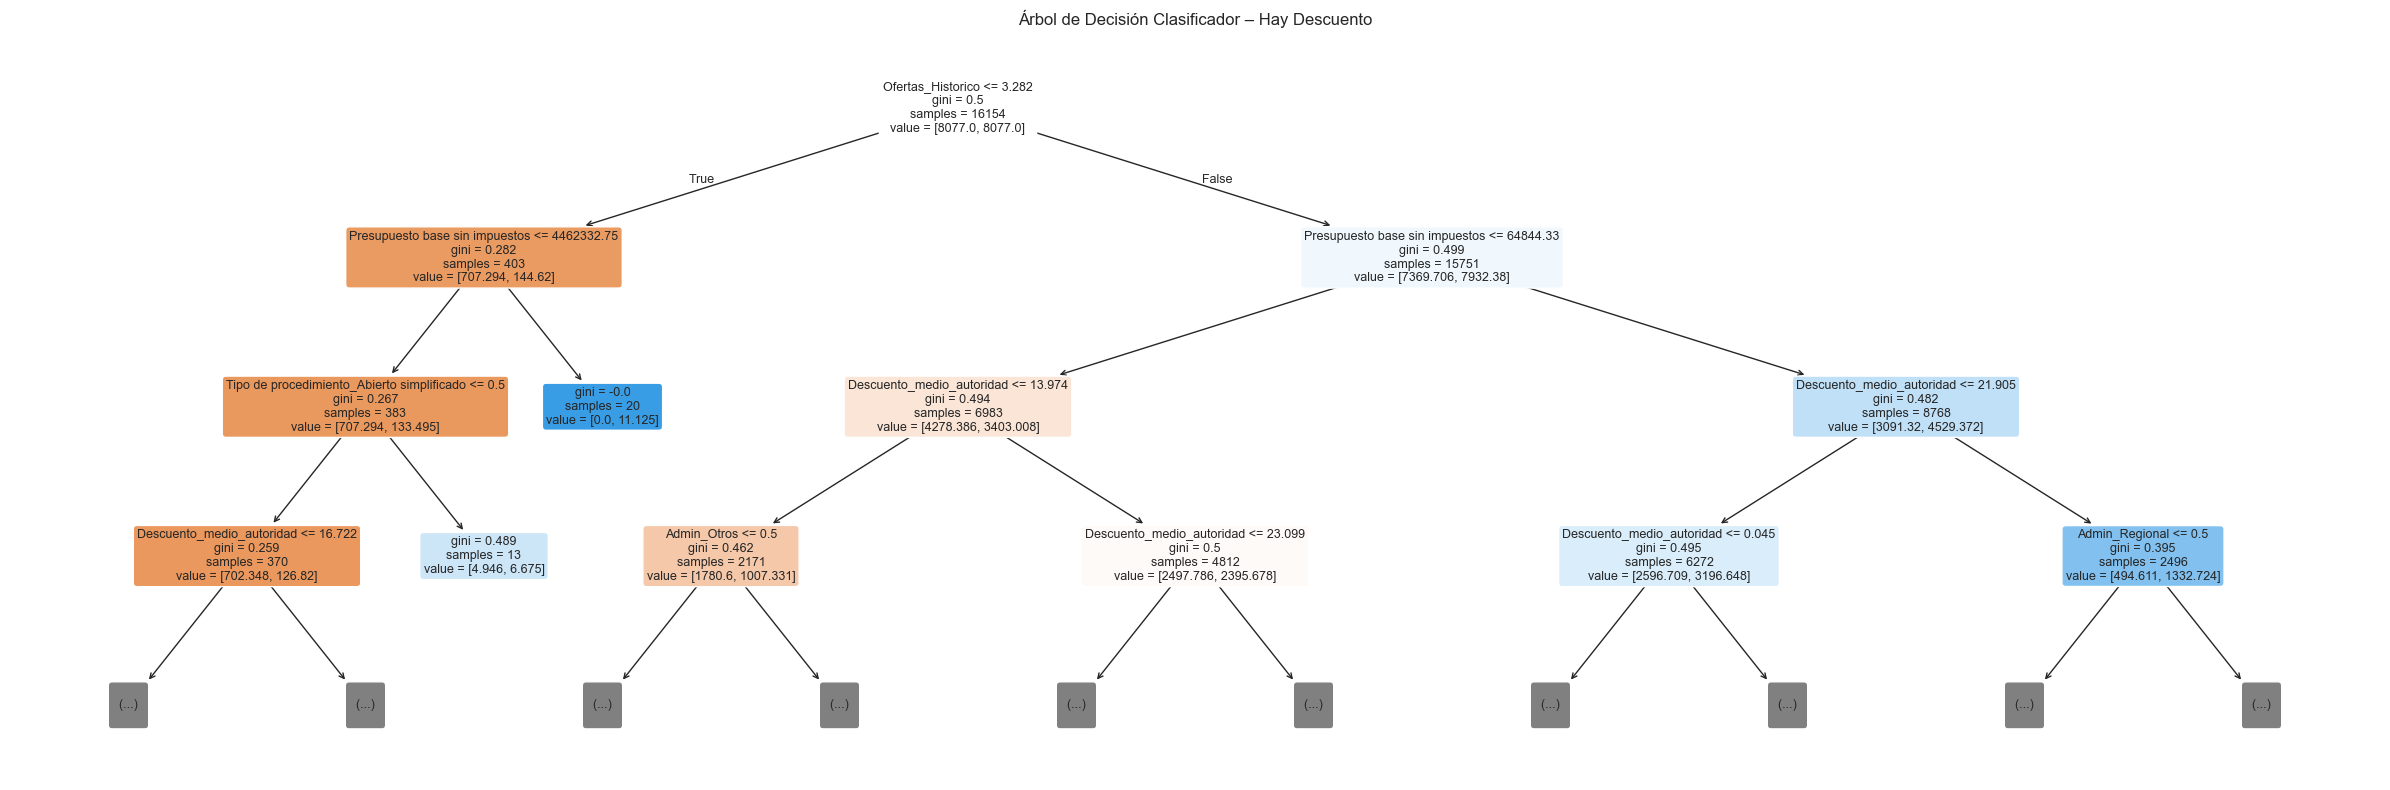

In [ ]:
plt.figure(figsize=(24, 8))
plot_tree(
    best_dt.named_steps['model'],
    feature_names=X_train_co.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3
)
plt.title('Árbol de Decisión Clasificador – Hay Descuento')
plt.tight_layout()
plt.show()

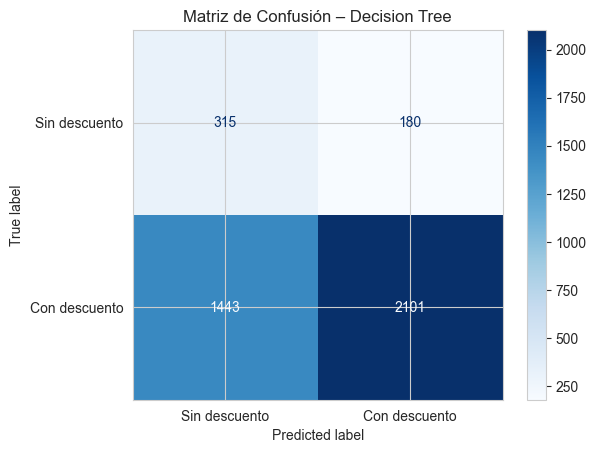

In [ ]:
cm = confusion_matrix(y_test_co, y_pred_dt_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Sin descuento', 'Con descuento'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión – Decision Tree')
plt.show()

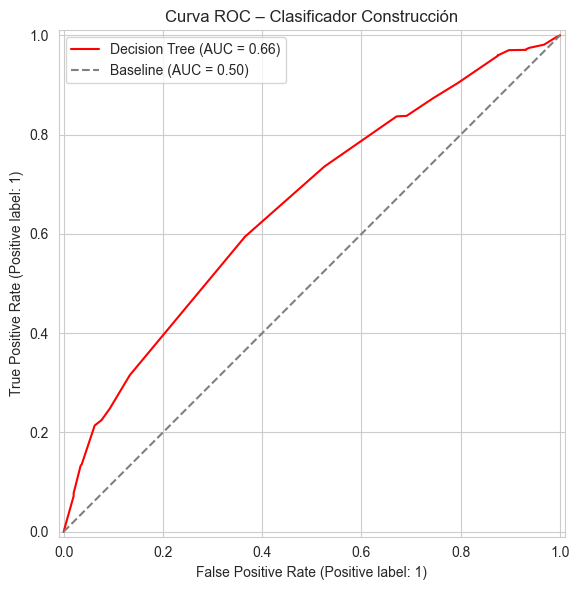

In [ ]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test_co,
    y_pred_proba_dt_clf,
    name='Decision Tree',
    color='red',
    ax=ax
)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Baseline (AUC = 0.50)')
ax.set_title('Curva ROC – Clasificador Construcción')
ax.legend()
plt.tight_layout()
plt.show()

Obtiene AUC_ROC de 0.66, parecido a la regresión logística. Es un punto intermedio entre los modelos anteriores ya que detecta 64% de contratos sin descuento. Ofrece un mejor equilibrio entre detectar ambos tipos, pero es peor si le damos más importancia a detectar contratos sin descuento.

## 6.1.5 Random Forest

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# class_weight='balanced' para compensar el desbalance 88.6% / 11.4%
# Sin descuento = 0.23 en el modelo base
pipeline_rf = Pipeline([
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1,
                                     class_weight='balanced'))
])

param_distribution = {
    'model__n_estimators':      [50, 100, 150, 200],
    'model__max_depth':         [10, 15, 20],
    'model__min_samples_split': [2, 5, 10, 20, 30],
    'model__min_samples_leaf':  [2, 4, 10]
}

random_search = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_distribution,
    n_iter=10,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train_co, y_train_co)

best_model_rf = random_search.best_estimator_
best_params   = random_search.best_params_
best_score    = random_search.best_score_

print("Best parameters:", best_params)
print(f"Best CV ROC-AUC: {best_score:.4f}")

y_pred_clf_co       = best_model_rf.predict(X_test_co)
y_pred_proba_clf_co = best_model_rf.predict_proba(X_test_co)[:, 1]

print(classification_report(y_test_co, y_pred_clf_co,
                             target_names=['Sin descuento', 'Con descuento']))
print(f"AUC-ROC: {roc_auc_score(y_test_co, y_pred_proba_clf_co):.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters: {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_depth': 20}
Best CV ROC-AUC: 0.6766
               precision    recall  f1-score   support

Sin descuento       0.41      0.27      0.32       495
Con descuento       0.90      0.95      0.92      3544

     accuracy                           0.86      4039
    macro avg       0.66      0.61      0.62      4039
 weighted avg       0.84      0.86      0.85      4039

AUC-ROC: 0.7322


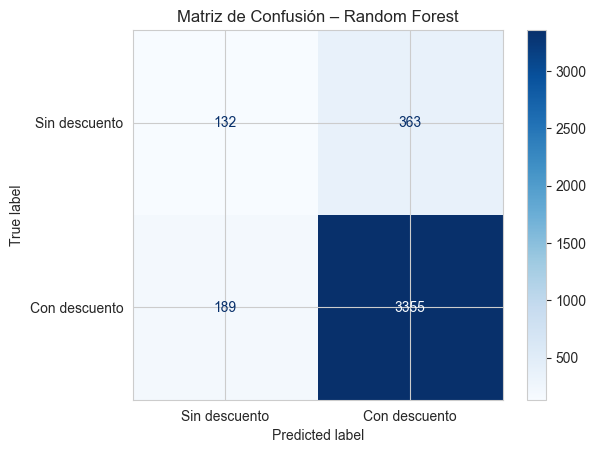

In [ ]:
cm = confusion_matrix(y_test_co, y_pred_clf_co)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Sin descuento', 'Con descuento'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión – Random Forest')
plt.show()

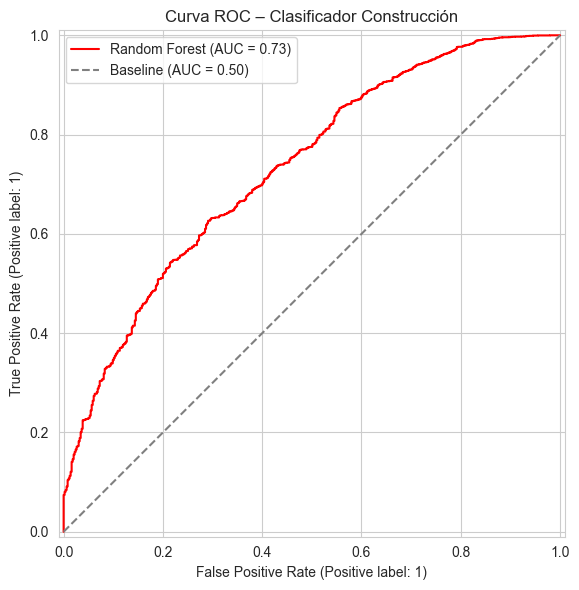

In [ ]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test_co,
    y_pred_proba_clf_co,
    name='Random Forest',
    color='red',
    ax=ax
)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Baseline (AUC = 0.50)')
ax.set_title('Curva ROC – Clasificador Construcción')
ax.legend()
plt.tight_layout()
plt.show()

El Random Forest es el mejor modelo hasta ahora con una AUC_ROC de 0.73. No es el óptimo para detectar sin descuento pero es el más equilibrado, siendo el mejor modelo hasta ahora con la mejor curva.

## 6.1.6 Gradient Boosting

Como Gradient Boosting tardaba mucho y no terminaba, probamos HistGradientBoosting que va más rápido

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

pipeline_hgb_clf = Pipeline([
    ('model', HistGradientBoostingClassifier(random_state=42))
])

param_distribution = {
    'model__max_iter':  [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth':     [3, 4, 5]
}

random_search_hgb_clf = RandomizedSearchCV(
    estimator=pipeline_hgb_clf,
    param_distributions=param_distribution,
    n_iter=10,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='roc_auc',
    n_jobs=8,
    random_state=42,
    verbose=1
)

random_search_hgb_clf.fit(X_train_co, y_train_co)

best_hgb_clf = random_search_hgb_clf.best_estimator_
print("Best params:", random_search_hgb_clf.best_params_)
print(f"Best CV ROC-AUC: {random_search_hgb_clf.best_score_:.4f}")

y_pred_hgb_clf       = best_hgb_clf.predict(X_test_co)
y_pred_proba_hgb_clf = best_hgb_clf.predict_proba(X_test_co)[:, 1]

print("=== Histogram Gradient Boosting Clasificador ===")
print(classification_report(y_test_co, y_pred_hgb_clf, target_names=['Sin descuento', 'Con descuento']))
print(f"AUC-ROC: {roc_auc_score(y_test_co, y_pred_proba_hgb_clf):.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'model__max_iter': 300, 'model__max_depth': 5, 'model__learning_rate': 0.01}
Best CV ROC-AUC: 0.6719
=== Histogram Gradient Boosting Clasificador ===
               precision    recall  f1-score   support

Sin descuento       0.90      0.09      0.17       495
Con descuento       0.89      1.00      0.94      3544

     accuracy                           0.89      4039
    macro avg       0.89      0.55      0.55      4039
 weighted avg       0.89      0.89      0.85      4039

AUC-ROC: 0.7283


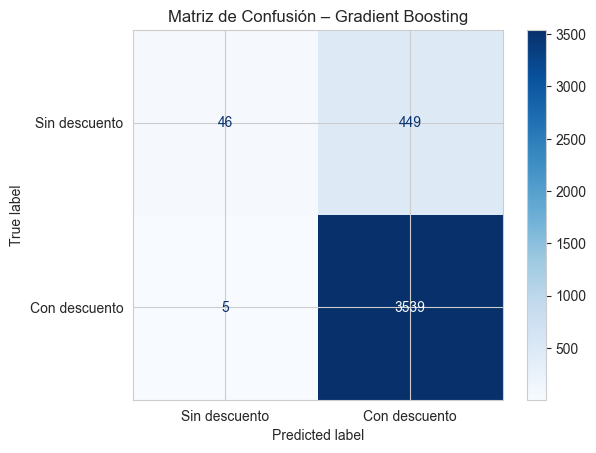

In [ ]:
cm = confusion_matrix(y_test_co, y_pred_hgb_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Sin descuento', 'Con descuento'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión – Gradient Boosting')
plt.show()

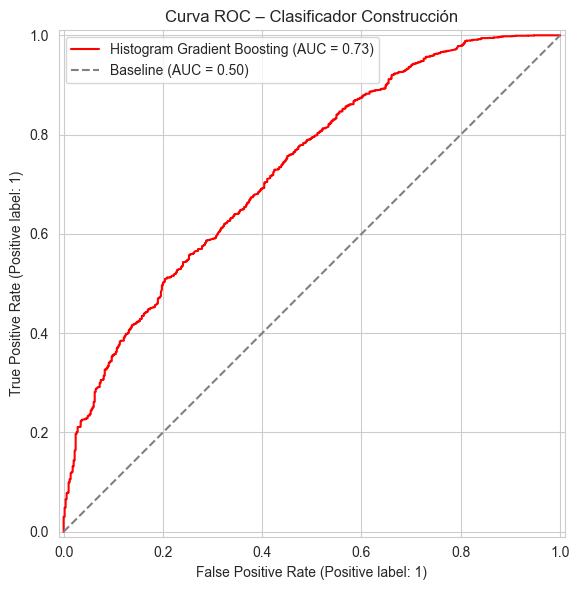

In [ ]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test_co,
    y_pred_proba_hgb_clf,
    name='Histogram Gradient Boosting',
    color='red',
    ax=ax
)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Baseline (AUC = 0.50)')
ax.set_title('Curva ROC – Clasificador Construcción')
ax.legend()
plt.tight_layout()
plt.show()

Obtiene un AUC_ROC de 0.73, idéntico al Random Forest, pero es más desequilibrado, ya que solo tiene un recall de 0,09 en contratos sin descuento.

## Resumen comparativo – Clasificadores

In [ ]:
print(f"{'Modelo':<25} {'AUC-ROC':>8}")
print("-" * 35)
print(f"{'Baseline':25} {'0.5000':>8}")
print(f"{'Regresión Logística':25} {roc_auc_score(y_test_co, y_pred_proba_lr_clf):>8.4f}")
print(f"{'KNN':25} {roc_auc_score(y_test_co, y_pred_proba_knn_clf):>8.4f}")
print(f"{'Decision Tree':25} {roc_auc_score(y_test_co, y_pred_proba_dt_clf):>8.4f}")
print(f"{'Random Forest':25} {roc_auc_score(y_test_co, y_pred_proba_clf_co):>8.4f}")
print(f"{'Histogram Gradient Boosting':25} {roc_auc_score(y_test_co, y_pred_proba_hgb_clf):>8.4f}")

Modelo                     AUC-ROC
-----------------------------------
Baseline                    0.5000
Regresión Logística         0.6909
KNN                         0.6213
Decision Tree               0.6559
Random Forest               0.7322
Histogram Gradient Boosting   0.7283


Según el caso de uso para el negocio, donde el objetivo principal es detectar los que no tienen descuento, nos quedamos con:

Random Forest > Regr. Logística > Decision Tree > Gradient Boosting > KNN.

## 6.2 Shap Clasificador

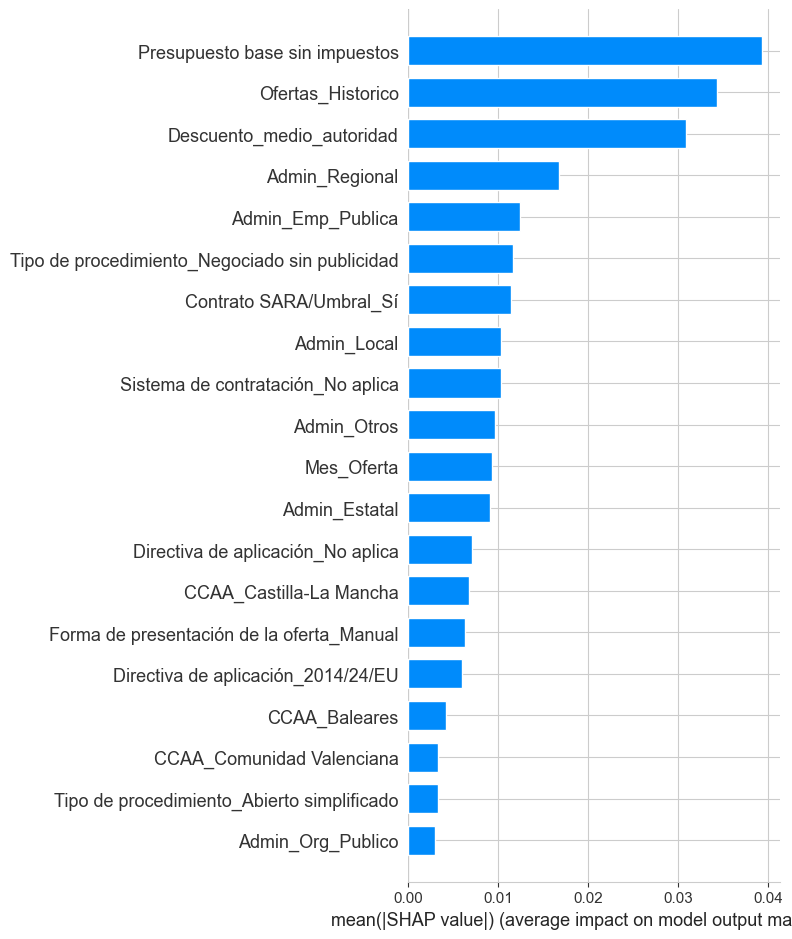

In [ ]:
explainer_clf = shap.TreeExplainer(best_model_rf.named_steps['model'])
X_test_sample = X_test_co.sample(2000, random_state=42)
shap_values_clf = explainer_clf.shap_values(X_test_sample)

# índice 1 = clase Con descuento
shap.summary_plot(shap_values_clf[:, :, 1], X_test_sample, plot_type='bar',
                  title='SHAP – Clasificador RF (¿Hay descuento?)')

Vemos que las variables más relevantes y que más explican son el descuento medio de la autoridad, el presupuesto y el sistema de contratación no definido. El hecho de ser una administración local o no también explica.

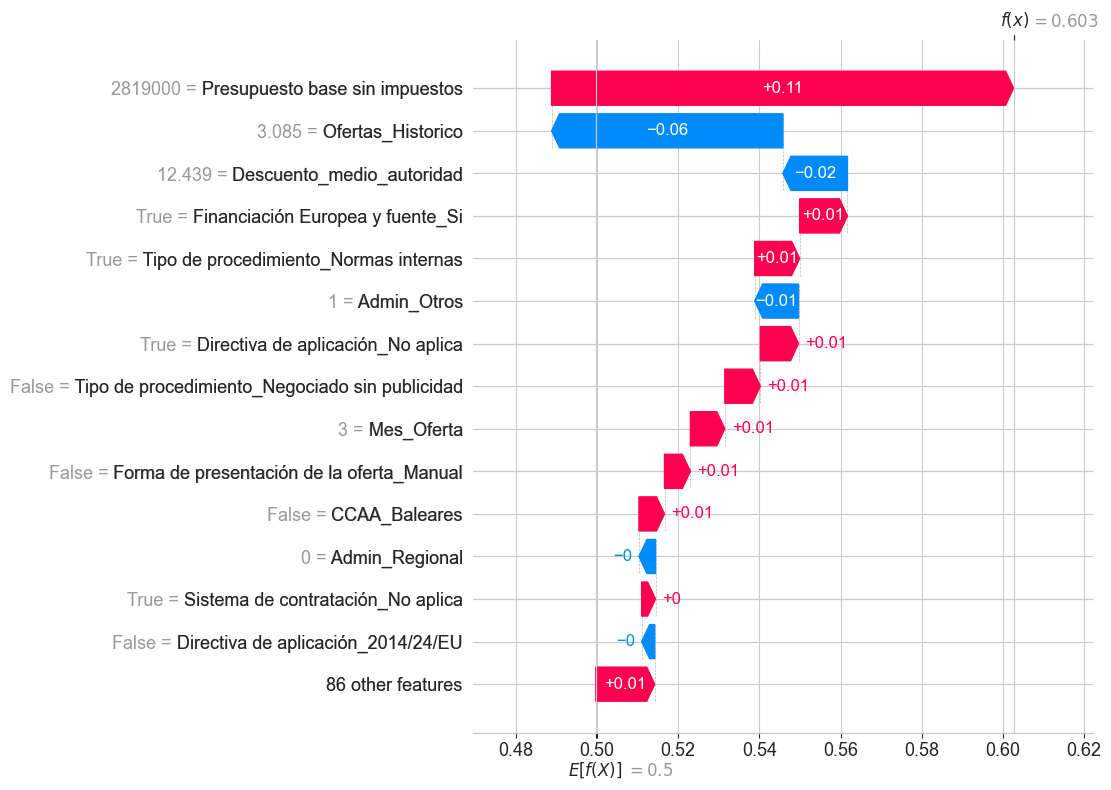

In [ ]:
explainer_clf = shap.TreeExplainer(best_model_rf.named_steps['model'])
X_test_sample = X_test_co.sample(2000, random_state=42).reset_index(drop=True)
shap_values_clf = explainer_clf(X_test_sample)

# Contrato número 246 (elegido al azar)
shap.plots.waterfall(shap_values_clf[:, :, 1][246], max_display=15)

En este caso concreto, ha aumentado la probabilidad de que esta licitación tenga descuento por el descuento medio de la autoridad (14,7%) y por no tener el sistema de contratación definido. El hecho de ser administración local ha bajado un poco su probabilidad de tener descuento.

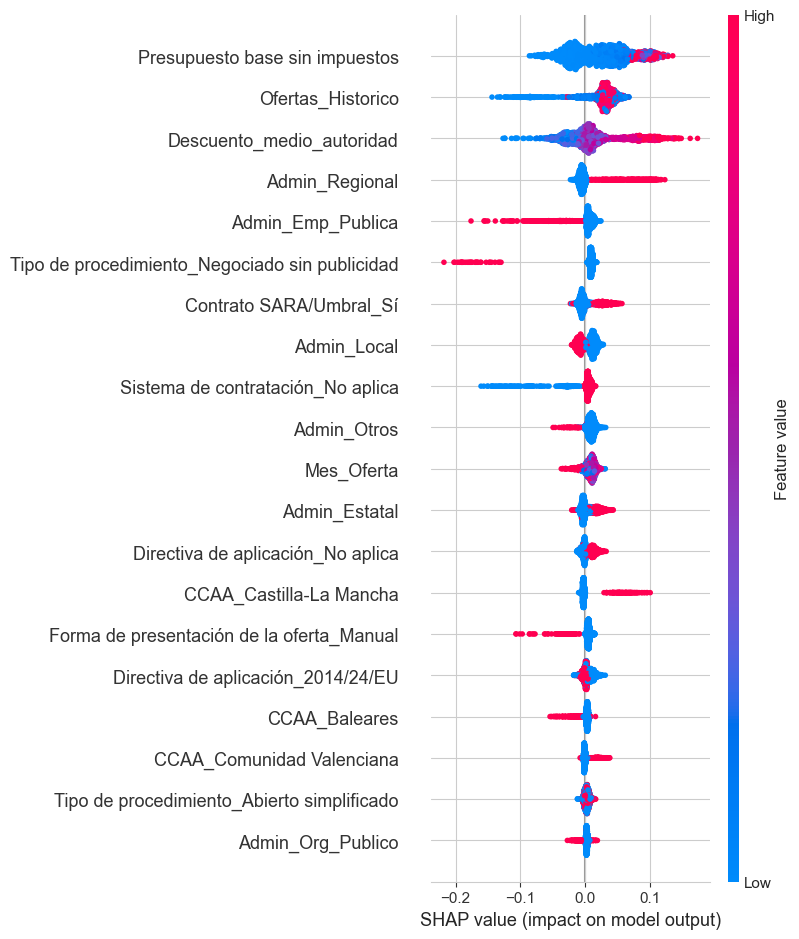

In [ ]:
explainer_clf = shap.TreeExplainer(best_model_rf.named_steps['model'])
X_test_sample = X_test_co.sample(2000, random_state=42).reset_index(drop=True)
shap_values_clf = explainer_clf(X_test_sample)

shap.summary_plot(
    shap_values_clf[:, :, 1].values,
    shap_values_clf[:, :, 1].data,
    feature_names=X_test_sample.columns,
    show=True
)

Los valores más altos de descuento medio de autoridad aumenta la probabilidad de que haya descuento, siendo la variable más determinante. En el caso del presupuesto base sin impuestos el impacto es algo más leve y en ofertas histórico el impacto es mixto.

# 6.2 Regresor

In [ ]:
# El regresor solo ve registros con descuento
cols_excluir = ['Target_Descuento', 'Hay_Descuento', 'Año_Oferta', 'CPV_Grupo']

# Filtrar solo registros con descuento > 0
df_train_reg = df_train_co[df_train_co['Target_Descuento'] > 0]
df_test_reg  = df_test_co[df_test_co['Target_Descuento'] > 0]

X_train_co = df_train_reg.drop(columns=cols_excluir, errors='ignore')
y_train_co = df_train_reg['Target_Descuento']

X_test_co = df_test_reg.drop(columns=cols_excluir, errors='ignore')
y_test_co = df_test_reg['Target_Descuento']

print(f"Train (con descuento): {len(df_train_reg)} registros")
print(f"Test  (con descuento): {len(df_test_reg)} registros")
print(f"X_train: {X_train_co.shape} | X_test: {X_test_co.shape}")

Train (con descuento): 14521 registros
Test  (con descuento): 3544 registros
X_train: (14521, 100) | X_test: (3544, 100)


## 6.2.1 Baseline

El baseline predice siempre la media del conjunto de entrenamiento. Es el mínimo que debe superar cualquier modelo.

In [ ]:
# Calculamos la media del train y la usamos como predicción constante sobre el test
media_train_co = y_train_co.mean()
y_pred_baseline_co = np.full(shape=len(y_test_co), fill_value=media_train_co)

mae_baseline_co = mean_absolute_error(y_test_co, y_pred_baseline_co)

print(f"Media del train (predicción constante): {media_train_co:.2f}%")
print(f"MAE Baseline: {mae_baseline_co:.2f}%")
print(f"R² Baseline:  0.00  (por definición matemática)")

Media del train (predicción constante): 23.20%
MAE Baseline: 14.46%
R² Baseline:  0.00  (por definición matemática)


Para cualquier contrato, el modelo usa el descuento de 14.51%.

## 6.2.2 Ridge (L2)

In [ ]:
from sklearn.linear_model import Ridge

pipeline_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

param_distribution = {
    'model__alpha': [0.01, 0.1, 1, 10, 100]
}

random_search_ridge = RandomizedSearchCV(
    estimator=pipeline_ridge,
    param_distributions=param_distribution,
    n_iter=5,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_ridge.fit(X_train_co, y_train_co)

best_ridge = random_search_ridge.best_estimator_
print("Best params:", random_search_ridge.best_params_)
print(f"Best CV MAE: {-random_search_ridge.best_score_:.4f}%")

y_pred_ridge_co = best_ridge.predict(X_test_co)

mae_ridge_co = mean_absolute_error(y_test_co, y_pred_ridge_co)
r2_ridge_co  = r2_score(y_test_co, y_pred_ridge_co)
print(f"MAE Ridge: {mae_ridge_co:.2f}%  |  R²: {r2_ridge_co:.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params: {'model__alpha': 100}
Best CV MAE: 13.8734%
MAE Ridge: 13.44%  |  R²: 0.0924


Mejora el MAE al 8.1%, una mejora del 19% respecto al baseline. Un R2 de 0.15 es coherente con el OLS (tiene sentido porque es una regresión pero con regularización). Esto indica que hay linealidad en los datos, pero también una alta varianza no lineal que los modelos más complejos tratarán de capturar.

## 6.2.3 KNN

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

pipeline_knn_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsRegressor())
])

param_distribution = {
    'model__n_neighbors': [5, 10, 15, 25, 50]
}

random_search_knn_reg = RandomizedSearchCV(
    estimator=pipeline_knn_reg,
    param_distributions=param_distribution,
    n_iter=5,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_knn_reg.fit(X_train_co, y_train_co)

best_knn_reg = random_search_knn_reg.best_estimator_
print("Best params:", random_search_knn_reg.best_params_)
print(f"Best CV MAE: {-random_search_knn_reg.best_score_:.4f}%")

y_pred_knn_co = best_knn_reg.predict(X_test_co)

mae_knn_co = mean_absolute_error(y_test_co, y_pred_knn_co)
r2_knn_co  = r2_score(y_test_co, y_pred_knn_co)
print(f"MAE KNN: {mae_knn_co:.2f}%  |  R²: {r2_knn_co:.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params: {'model__n_neighbors': 50}
Best CV MAE: 14.5615%
MAE KNN: 14.05%  |  R²: 0.0341


Mejora el MAE al 14,05%, peor que el Ridge. Al igual que en clasificador, alto número de vecinos indica que no están muy separadas las clases. Un modelo lineal supera al KNN. De momento este modelo no sirve mucho. Además tiene R2 menor.

## 6.2.4 Decision Tree

In [ ]:
pipeline_dt_reg = Pipeline([
    ('model', DecisionTreeRegressor(random_state=42))
])

param_distribution = {
    'model__max_depth':        [3, 4, 6, 8, 10],
    'model__min_samples_leaf': [10, 20, 30, 50]
}

random_search_dt_reg = RandomizedSearchCV(
    estimator=pipeline_dt_reg,
    param_distributions=param_distribution,
    n_iter=10,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_dt_reg.fit(X_train_co, y_train_co)

best_dt_reg = random_search_dt_reg.best_estimator_
print("Best params:", random_search_dt_reg.best_params_)
print(f"Best CV MAE: {-random_search_dt_reg.best_score_:.4f}%")

y_pred_dt_co = best_dt_reg.predict(X_test_co)

mae_dt_co = mean_absolute_error(y_test_co, y_pred_dt_co)
r2_dt_co  = r2_score(y_test_co, y_pred_dt_co)
print(f"MAE Decision Tree: {mae_dt_co:.2f}%  |  R²: {r2_dt_co:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'model__min_samples_leaf': 20, 'model__max_depth': 4}
Best CV MAE: 13.7260%
MAE Decision Tree: 13.40%  |  R²: 0.0824


Mejora al KNN sin llegar al Ridge. un modelo no lineal con alta profundidad no mejora al lineal. La linealidad supera la no linealidad. No mejora al Ridge.

## 6.2.5 Random Forest

In [ ]:
pipeline_rf_reg = Pipeline([
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_distribution = {
    'model__n_estimators':      [50, 100, 150, 200],
    'model__max_depth':         [10, 15, 20],
    'model__min_samples_split': [2, 5, 10, 20, 30],
    'model__min_samples_leaf':  [2, 4, 10]
}

# scoring='neg_mean_absolute_error': optimizamos MAE
# KFold en lugar de StratifiedKFold porque el target es continuo, no hay clases
random_search_reg = RandomizedSearchCV(
    estimator=pipeline_rf_reg,
    param_distributions=param_distribution,
    n_iter=10,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_reg.fit(X_train_co, y_train_co)

best_model_rf_reg = random_search_reg.best_estimator_
best_params_reg   = random_search_reg.best_params_
best_score_reg    = -random_search_reg.best_score_  # negativo positivo

print("Best parameters:", best_params_reg)
print(f"Best CV MAE: {best_score_reg:.4f}%")

rf_co        = best_model_rf_reg
y_pred_rf_co = rf_co.predict(X_test_co)

mae_rf_co = mean_absolute_error(y_test_co, y_pred_rf_co)
r2_rf_co  = r2_score(y_test_co, y_pred_rf_co)
mejora_co = (mae_baseline_co - mae_rf_co) / mae_baseline_co * 100

print(f"MAE Random Forest: {mae_rf_co:.2f}%")
print(f"R²  Random Forest: {r2_rf_co:.4f}")
print(f"\nMejora sobre el baseline: {mejora_co:.1f}%")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters: {'model__n_estimators': 200, 'model__min_samples_split': 20, 'model__min_samples_leaf': 2, 'model__max_depth': 10}
Best CV MAE: 13.6256%
MAE Random Forest: 13.04%
R²  Random Forest: 0.1203

Mejora sobre el baseline: 9.9%


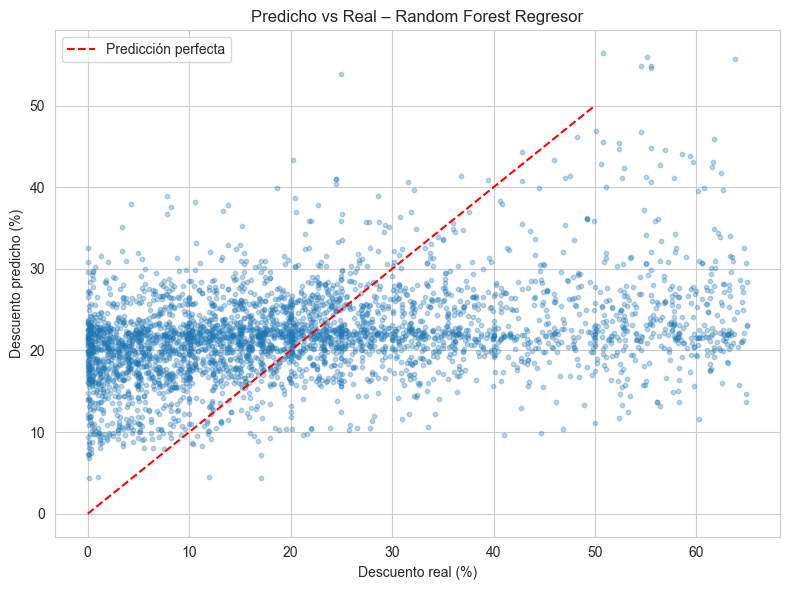

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_co, y_pred_rf_co, alpha=0.3, s=10)
plt.plot([0, 50], [0, 50], 'r--', label='Predicción perfecta')
plt.xlabel('Descuento real (%)')
plt.ylabel('Descuento predicho (%)')
plt.title('Predicho vs Real – Random Forest Regresor')
plt.legend()
plt.tight_layout()
plt.show()

## 6.2.6 Gradient Boosting

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

pipeline_hgb = Pipeline([
    ('model', HistGradientBoostingRegressor(random_state=42))
])

param_distribution = {
    'model__max_iter':  [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth':     [3, 4, 5]
}

random_search_hgb = RandomizedSearchCV(
    estimator=pipeline_hgb,
    param_distributions=param_distribution,
    n_iter=10,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='neg_mean_absolute_error',
    n_jobs=8,
    random_state=42,
    verbose=1
)

random_search_hgb.fit(X_train_co, y_train_co)

best_hgb = random_search_hgb.best_estimator_
print("Best params:", random_search_hgb.best_params_)
print(f"Best CV MAE: {-random_search_hgb.best_score_:.4f}%")

hgb_co        = best_hgb
y_pred_hgb_co = hgb_co.predict(X_test_co)

mae_hgb_co    = mean_absolute_error(y_test_co, y_pred_hgb_co)
r2_hgb_co     = r2_score(y_test_co, y_pred_hgb_co)
mejora_hgb_co = (mae_baseline_co - mae_hgb_co) / mae_baseline_co * 100

print(f"MAE Histogram Gradient Boosting: {mae_hgb_co:.2f}%")
print(f"R²  Histogram Gradient Boosting: {r2_hgb_co:.4f}")
print(f"\nMejora sobre el baseline: {mejora_hgb_co:.1f}%")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'model__max_iter': 100, 'model__max_depth': 4, 'model__learning_rate': 0.05}
Best CV MAE: 13.6495%
MAE Histogram Gradient Boosting: 13.10%
R²  Histogram Gradient Boosting: 0.1178

Mejora sobre el baseline: 9.4%


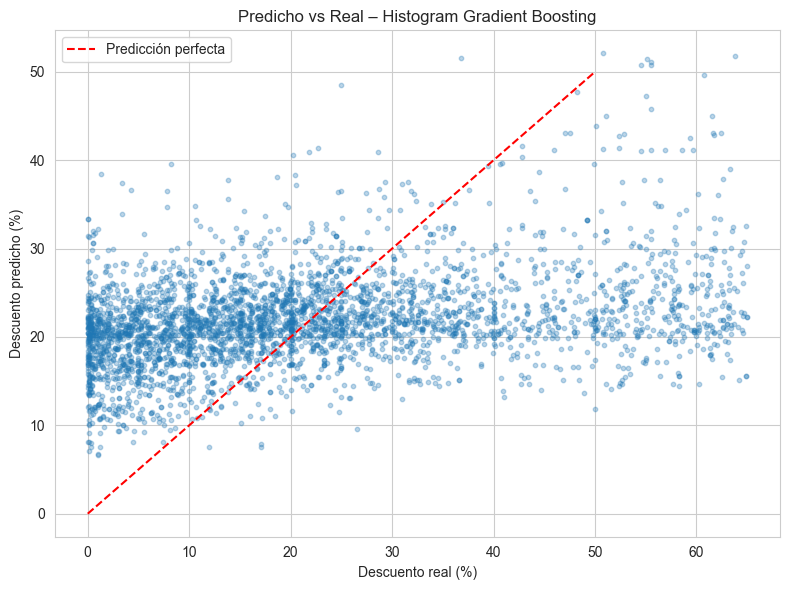

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_co, y_pred_hgb_co, alpha=0.3, s=10)
plt.plot([0, 50], [0, 50], 'r--', label='Predicción perfecta')
plt.xlabel('Descuento real (%)')
plt.ylabel('Descuento predicho (%)')
plt.title('Predicho vs Real – Histogram Gradient Boosting')
plt.legend()
plt.tight_layout()
plt.show()

## Resumen comparativo

In [ ]:
print(f"{'Modelo':<30} {'MAE':>8} {'R²':>8} {'Mejora':>8}")
print("-" * 53)
print(f"{'Baseline (media)':30} {mae_baseline_co:>7.2f}%  {'0.0000':>8}  {'—':>8}")
print(f"{'Ridge':30} {mae_ridge_co:>7.2f}%  {r2_ridge_co:>8.4f}  {(mae_baseline_co - mae_ridge_co) / mae_baseline_co * 100:>7.1f}%")
print(f"{'KNN':30} {mae_knn_co:>7.2f}%  {r2_knn_co:>8.4f}  {(mae_baseline_co - mae_knn_co) / mae_baseline_co * 100:>7.1f}%")
print(f"{'Decision Tree':30} {mae_dt_co:>7.2f}%  {r2_dt_co:>8.4f}  {(mae_baseline_co - mae_dt_co) / mae_baseline_co * 100:>7.1f}%")
print(f"{'Random Forest':30} {mae_rf_co:>7.2f}%  {r2_rf_co:>8.4f}  {(mae_baseline_co - mae_rf_co) / mae_baseline_co * 100:>7.1f}%")
print(f"{'Histogram Gradient Boosting':30} {mae_hgb_co:>7.2f}%  {r2_hgb_co:>8.4f}  {mejora_hgb_co:>7.1f}%")

Modelo                              MAE       R²   Mejora
-----------------------------------------------------
Baseline (media)                 14.46%    0.0000         —
Ridge                            13.44%    0.0924      7.0%
KNN                              14.05%    0.0341      2.8%
Decision Tree                    13.40%    0.0824      7.3%
Random Forest                    13.04%    0.1203      9.9%
Histogram Gradient Boosting      13.10%    0.1178      9.4%


## Shap Regresor

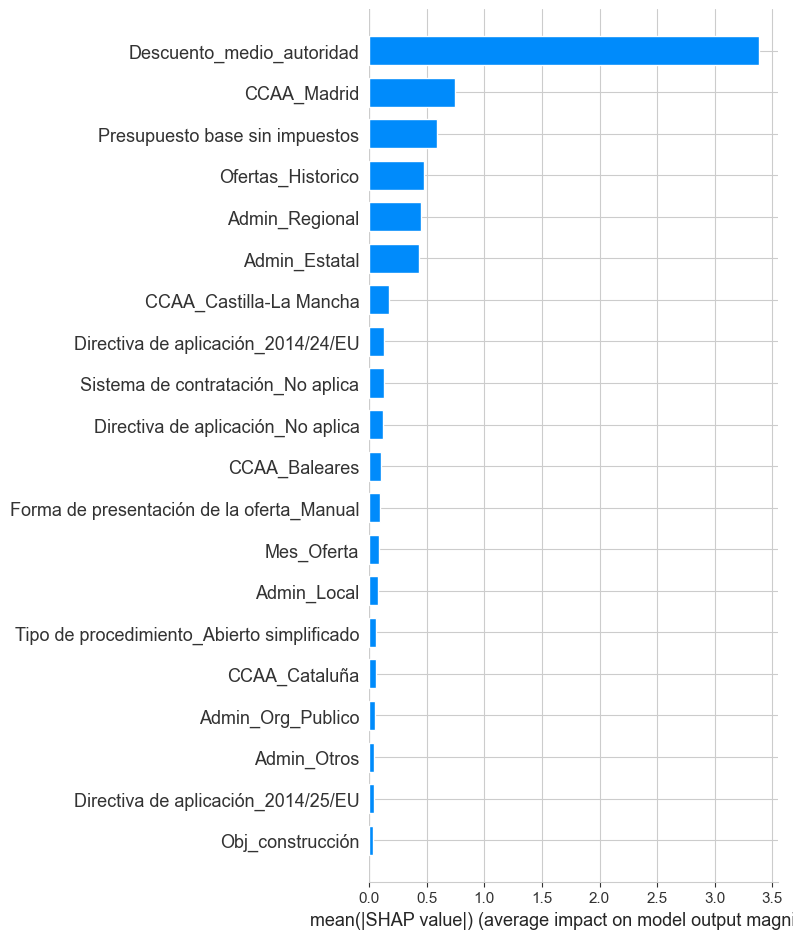

In [ ]:
explainer_reg = shap.TreeExplainer(hgb_co.named_steps['model'])
X_test_reg_sample = X_test_co.sample(2000, random_state=42)
shap_values_reg = explainer_reg.shap_values(X_test_reg_sample)

shap.summary_plot(shap_values_reg, X_test_reg_sample, plot_type='bar',
                  title='SHAP – Regresor HGB (% de descuento)')

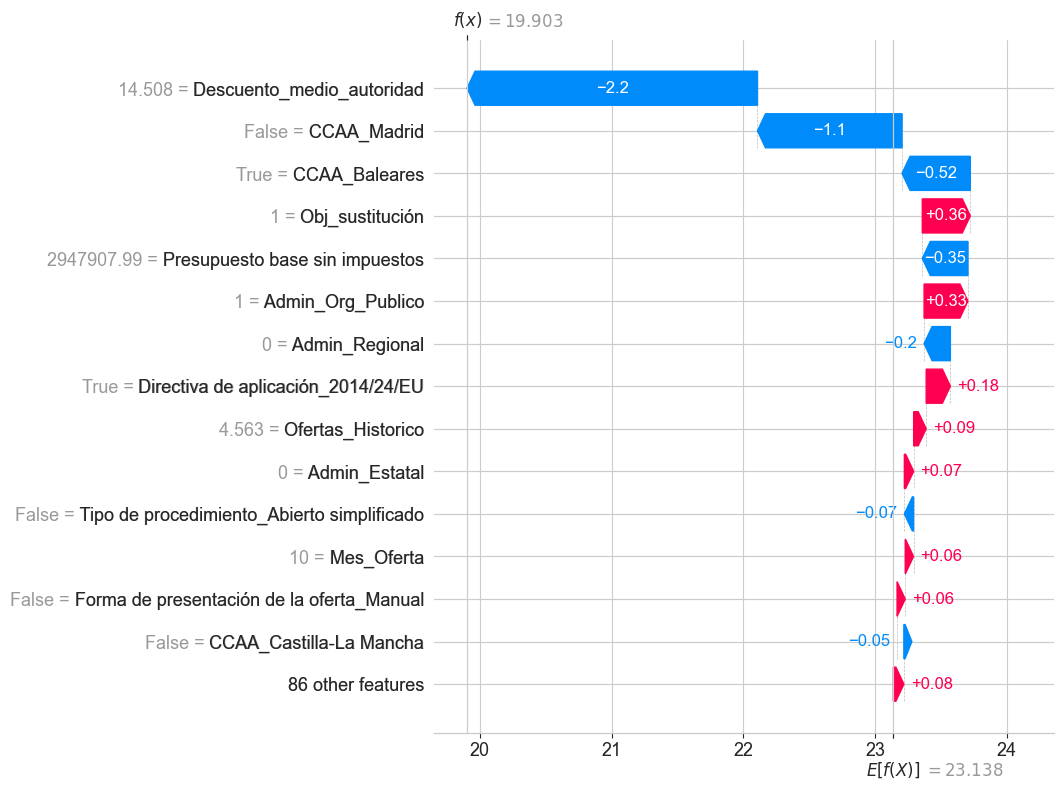

In [ ]:
explainer_reg = shap.TreeExplainer(hgb_co.named_steps['model'])
X_test_reg_sample = X_test_co.sample(2000, random_state=42).reset_index(drop=True)
shap_values_reg = explainer_reg(X_test_reg_sample)

shap.plots.waterfall(shap_values_reg[98], max_display=15)

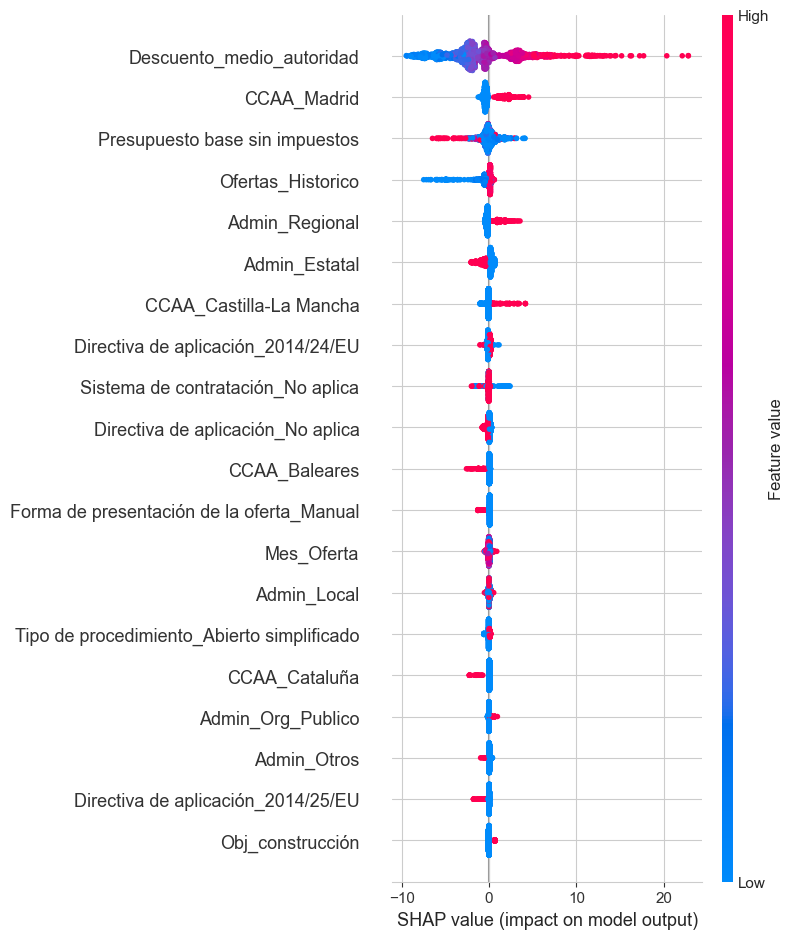

In [ ]:
# Beeswarm Regresor (HGB)
explainer_reg = shap.TreeExplainer(hgb_co.named_steps['model'])
X_test_reg_sample = X_test_co.sample(2000, random_state=42).reset_index(drop=True)
shap_values_reg = explainer_reg(X_test_reg_sample)

shap.summary_plot(
    shap_values_reg.values,
    shap_values_reg.data,
    feature_names=X_test_reg_sample.columns,
    show=True
)

Los valores altos del descuento medio de autoridad se extienden fuertemente a la derecha, siendo el principal driver del descuento predicho. En el caso de numero de ofertas los valores altos tienden a tener menor descuento porcentual.